# 0. library import & Data load

In [1]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import datetime
from warnings import simplefilter
from functools import partial

from tqdm.auto import tqdm
import datetime as dt
from pathlib import Path

tqdm.pandas()

simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
simplefilter(action="ignore", category=pd.errors.DtypeWarning)
pd.set_option('display.max_columns', None)

from pandarallel import pandarallel
pandarallel.initialize()

INFO: Pandarallel will run on 64 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
store_dir = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/"

In [3]:
# # MIMIC 3.1 csv.gz -> feather

# import time
# import os

# def convert_csv_gz_to_feather(base_dir_path):
#     base_dir = Path(base_dir_path)
#     target_dirs = [base_dir / 'hosp', base_dir / 'icu']
    
#     for target_dir in target_dirs:
#         if not target_dir.exists():
#             print(f"⚠️ 폴더를 찾을 수 없습니다: {target_dir}")
#             continue
            
#         # 1. 일단 폴더 내의 모든 .csv.gz 파일을 찾습니다.
#         all_files = list(target_dir.glob('*.csv.gz'))
        
#         if not all_files:
#             print(f"📂 {target_dir.name} 폴더에 변환할 .csv.gz 파일이 없습니다.")
#             continue
            
#         # 🔥 [핵심] 파일 크기(Bytes)가 작은 순서대로 정렬합니다!
#         csv_files = sorted(all_files, key=lambda p: os.path.getsize(p))
        
#         print(f"\n📂 {target_dir.name} 폴더 변환 시작 (총 {len(csv_files)}개 파일 - 작은 파일부터 처리)")
        
#         for csv_path in tqdm(csv_files, desc=f"{target_dir.name} 전체 진행률"):
#             file_name = Path(csv_path.stem).stem
#             feather_path = target_dir / f"{file_name}.ftr"
            
#             if feather_path.exists():
#                 continue
                
#             file_size_mb = os.path.getsize(csv_path) / (1024 * 1024)
            
#             tqdm.write(f"⏳ 변환 중: {csv_path.name} ({file_size_mb:.1f} MB) ➔ {feather_path.name}")
#             start_time = time.time()
            
#             try:
#                 df = pd.read_csv(csv_path, low_memory=False)
#                 df.to_feather(feather_path)
#                 elapsed_time = time.time() - start_time
#                 tqdm.write(f"  ✅ 완료! ({elapsed_time:.2f}초 소요)\n")
                
#             except Exception as e:
#                 tqdm.write(f"  ❌ 에러 발생 ({csv_path.name}): {e}\n")

In [4]:
# RAW_DIR = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/"
# convert_csv_gz_to_feather(RAW_DIR)

In [5]:
# data path
core_mimiciv_path = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/"
# core_mimiciv_imgcxr_path = 'C:/Users/gangmin/dahs/data/physionet.org/files/mimic-cxr-jpg/2.1.0/'

In [6]:
# MIMIC-IV V 3.1
## core
df_admissions = pd.read_feather(core_mimiciv_path + 'hosp/admissions.ftr')
df_patients = pd.read_feather(core_mimiciv_path + 'hosp/patients.ftr')
df_transfers = pd.read_feather(core_mimiciv_path + 'hosp/transfers.ftr')

## hosp
df_diagicd = pd.read_feather(core_mimiciv_path + "hosp/diagnoses_icd.ftr")
df_procicd = pd.read_feather(core_mimiciv_path + "hosp/procedures_icd.ftr")
df_lab = pd.read_feather(core_mimiciv_path + "hosp/labevents.ftr")
df_prscr = pd.read_feather(core_mimiciv_path + "hosp/prescriptions.ftr")
df_micro = pd.read_feather(core_mimiciv_path + "hosp/microbiologyevents.ftr")
df_omr = pd.read_feather(core_mimiciv_path + "hosp/omr.ftr")
df_dlabitems = pd.read_feather(core_mimiciv_path + "hosp/d_labitems.ftr")

## icu
df_icustays = pd.read_feather(core_mimiciv_path + 'icu/icustays.ftr')
df_chart = pd.read_feather(core_mimiciv_path + "icu/chartevents.ftr")
df_input = pd.read_feather(core_mimiciv_path + "icu/inputevents.ftr")
df_output = pd.read_feather(core_mimiciv_path + "icu/outputevents.ftr")
df_proc = pd.read_feather(core_mimiciv_path + "icu/procedureevents.ftr")
df_ditems = pd.read_feather(core_mimiciv_path + "icu/d_items.ftr")

In [7]:
# unnecessary column drop
df_chart = df_chart.drop(columns=['storetime', 'warning', 'caregiver_id'])

tmp = ['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'itemid', 'amount', 'amountuom', 'rate', 'rateuom', 'patientweight']
df_input = df_input.drop(columns=[col for col in df_input.columns if col not in tmp])

df_output = df_output.drop(columns=['storetime', 'caregiver_id'])

tmp = ['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'itemid', 'value', 'valueuom', 'patientweight']
df_proc = df_proc.drop(columns=[col for col in df_proc.columns if col not in tmp])

tmp = ['subject_id', 'hadm_id', 'specimen_id', 'itemid', 'charttime', 'value', 'valuenum', 'valueuom']
df_lab = df_lab.drop(columns=[col for col in df_lab.columns if col not in tmp])

tmp = ['subject_id', 'hadm_id', 'starttime', 'stoptime', 'drug']
df_prscr = df_prscr.drop(columns=[col for col in df_prscr.columns if col not in tmp])
df_prscr.columns = [col if col != 'stoptime' else 'endtime' for col in df_prscr.columns]

tmp = ['subject_id', 'hadm_id', 'charttime', 'spec_type_desc', 'org_name'] # spec_itemid -> spec_type_desc, 
df_micro = df_micro.drop(columns = [col for col in df_micro.columns if col not in tmp])
df_micro.columns = [col if col != 'spec_type_desc' else 'itemid' for col in df_micro.columns ]

In [8]:
# 각 데이터셋에 포함된 여러 시간 정보를 str 자료형에서 datetime 자료형으로 변경
df_list = [df_admissions, df_transfers, df_icustays, df_chart, df_input, df_proc, df_output, df_procicd, df_lab, df_prscr, df_micro, df_omr]

for df in tqdm(df_list):
    # chart, output, lab, microbiology 
    if 'charttime' in df.columns:
        df['charttime'] = pd.to_datetime(df['charttime'])
        df = df.sort_values(['subject_id', 'charttime']).reset_index(drop=True)
    
    # input, procedure, prescription
    elif 'endtime' in df.columns:
        df['starttime'] = pd.to_datetime(df['starttime'])
        df['endtime'] = pd.to_datetime(df['endtime'])
        df = df.sort_values(['subject_id', 'starttime']).reset_index(drop=True)

    # admission, 
    elif 'admittime' in df.columns:
        df['admittime'] = pd.to_datetime(df['admittime'])
        df['dischtime'] = pd.to_datetime(df['dischtime'])
        df = df.sort_values(['subject_id', 'admittime']).reset_index(drop=True)
    
    # procicd, omr
    elif 'chartdate' in df.columns:
        df['chartdate'] = pd.to_datetime(df['chartdate'])
        df = df.sort_values(['subject_id', 'chartdate']).reset_index(drop=True)

    # transfers, icustays
    elif 'intime' in df.columns:
        df['intime'] = pd.to_datetime(df['intime'])
        df['outtime'] = pd.to_datetime(df['outtime'])
        df = df.sort_values(['subject_id', 'intime']).reset_index(drop=True)

  0%|          | 0/12 [00:00<?, ?it/s]

In [9]:
static_info = pd.read_csv('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/hosp/static_info.csv')
static_info

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty
0,NaN,22595853.0,10000032,NaN,NaN,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-05-06 19:17:00,2180-05-06 23:30:00,NaN,NaN,TRANSFER FROM HOSPITAL,HOME,URGENT,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.347761,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
1,NaN,22841357.0,10000032,NaN,NaN,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-06-26 15:54:00,2180-06-26 21:31:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.487038,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
2,39553978.0,29079034.0,10000032,2180-07-23 14:00:00,2180-07-23 23:50:47,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,0.410266,F,52,2180-01-01,2014 - 2016,52.560502,52.560341,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
3,NaN,25742920.0,10000032,NaN,NaN,2180-08-05 23:44:00,2180-08-07 17:50:00,2180-08-05 20:58:00,2180-08-06 01:44:00,NaN,NaN,EMERGENCY ROOM,HOSPICE,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.597230,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
4,NaN,25022803.0,10000068,NaN,NaN,2160-03-03 23:16:00,2160-03-04 06:26:00,2160-03-03 21:55:00,2160-03-04 06:26:00,NaN,NaN,EMERGENCY ROOM,NaN,EU OBSERVATION,NaN,English,SINGLE,NaN,F,19,2160-01-01,2008 - 2010,NaN,19.172519,WHITE,survived,0,NaN,NaN,certain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552824,NaN,29734428.0,19999828,NaN,NaN,2147-07-18 16:23:00,2147-08-04 18:10:00,2147-07-17 17:18:00,2147-07-18 17:34:00,NaN,NaN,PHYSICIAN REFERRAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,NaN,F,46,2147-01-01,2017 - 2019,NaN,46.544336,WHITE,survived,0,NaN,NaN,certain
552825,36075953.0,25744818.0,19999828,2149-01-08 18:12:00,2149-01-10 13:11:02,2149-01-08 16:44:00,2149-01-18 17:00:00,2149-01-08 09:11:00,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),TRANSFER FROM HOSPITAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,1.790995,F,46,2147-01-01,2017 - 2019,48.023995,48.023828,WHITE,survived,0,NaN,NaN,certain
552826,NaN,26071774.0,19999840,NaN,NaN,2164-07-25 00:27:00,2164-07-28 12:15:00,2164-07-24 21:16:00,2164-07-25 01:20:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Private,English,WIDOWED,NaN,M,58,2164-01-01,2008 - 2010,NaN,58.564435,WHITE,in,0,2164-09-17 13:42:00,0.0,certain
552827,38978960.0,21033226.0,19999840,2164-09-12 09:26:28,2164-09-17 16:35:15,2164-09-10 13:47:00,2164-09-17 16:35:15,2164-09-10 11:09:00,2164-09-10 14:46:00,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,DIED,EW EMER.,Private,English,WIDOWED,5.297766,M,58,2164-01-01,2008 - 2010,58.699708,58.694724,WHITE,in,1,2164-09-17 13:42:00,0.0,certain


In [10]:
static_info.columns

Index(['stay_id', 'hadm_id', 'subject_id', 'intime', 'outtime', 'admittime',
       'dischtime', 'edregtime', 'edouttime', 'first_careunit',
       'last_careunit', 'admission_location', 'discharge_location',
       'admission_type', 'insurance', 'language', 'marital_status', 'los',
       'gender', 'anchor_age', 'anchor_year', 'anchor_year_group',
       'age_at_intime', 'age_at_admittime', 'race', 'deathtype', 'death_adm',
       'deathtime', 'is_dht_date', 'certainty'],
      dtype='object')

# 1. Data validation

- 시간(admittime, dischtime, intime, outtime)의 선행관계에 문제가 있는 경우 해당 행을 삭제함.

In [11]:
key_id = df_icustays[['subject_id', 'hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)
key_id

,subject_id,hadm_id,stay_id
0,10000032,29079034,39553978
1,10000690,25860671,37081114
2,10000980,26913865,39765666
3,10001217,24597018,37067082
4,10001217,27703517,34592300
...,...,...,...
94453,19999442,26785317,32336619
94454,19999625,25304202,31070865
94455,19999828,25744818,36075953
94456,19999840,21033226,38978960


## Step 1. 입원 시간이 퇴원 시간보다 늦은 입원 기록은 제외됨.

In [12]:
print("전처리 이전, 입원 시간이 퇴원 시간보다 늦은 입원 기록 행수: ", len(df_admissions[df_admissions['admittime'] > df_admissions['dischtime']]))

전처리 이전, 입원 시간이 퇴원 시간보다 늦은 입원 기록 행수:  175


In [13]:
df1 = key_id[['subject_id', 'hadm_id']]
df1 = df1.merge(df_admissions, on=['subject_id', 'hadm_id'], how='left') # admission에는 stay_id 없는데 병합했음(hadm_id 같고 stay_id 다른 경우 붙음)

filtered_df1 = df1[df1['admittime'] > df1['dischtime']]
print("key_id 추출 시 Step 1에서 삭제 대상 행수: ", len(filtered_df1))

drop_rows = filtered_df1[['subject_id', 'hadm_id']]
key_id = key_id[~key_id[['subject_id', 'hadm_id']].isin(drop_rows).all(axis=1)]
print("삭제처리 완료 후 key_id 행수: ", len(key_id))

key_id 추출 시 Step 1에서 삭제 대상 행수:  81
삭제처리 완료 후 key_id 행수:  94377


## Step 2. 시작 시간이 종료 시간보다 늦은 약물, 또는 약물 시작 시간이 환자 퇴원 이후인 약물도 제거됨.

In [14]:
key_id.stay_id.nunique()

94377

In [15]:
df_adm = key_id.merge(df_admissions, on=['subject_id', 'hadm_id'], how='left')
df1 = df_input.merge(key_id, how='right', on=['subject_id', 'hadm_id', 'stay_id'])

In [16]:
print("기존 inputevents 행수: ", len(df_input))
print("cxr 확보 inputevents 행수: ", len(df1))

기존 inputevents 행수:  10953713
cxr 확보 inputevents 행수:  10961356


In [17]:
# Step 2-1. 약물 시작 시간이 종료 시간보다 늦은 약물
print("약물 시작 시간이 종료 시간보다 늦은 약물 행수: ", len(df1[df1['starttime'] > df1['endtime']]))

# Step 2-1 처리
df1 = df1[df1['starttime'] <= df1['endtime']]

약물 시작 시간이 종료 시간보다 늦은 약물 행수:  10


In [18]:
# Step 2-2. 약물의 amount가 음수인 경우
print("약물의 amount가 음수인 경우: ", len(df1[df1['amount'] < 0]))

# Step 2-2 처리
df1 = df1[df1['amount'] >= 0]

약물의 amount가 음수인 경우:  8


- df_admissions: 전체 데이터셋의 demograpic info
- df_adm: cxr이 있는 경우에 한해서 demograpic info

In [19]:
df_adm.stay_id.nunique()

94377

In [20]:
df_adm = df_adm[['stay_id', 'admittime', 'dischtime']]

# input event가 없는 경우를 삭제해서 key_id를 재편함.
key_id = df1[['stay_id']].drop_duplicates().reset_index(drop=True)
print(len(key_id))

84274


In [21]:
df_adm = key_id.merge(df_adm, on='stay_id')

In [22]:
# Step 2-3. 약물 시작 시간이 환자 퇴원 이후인 경우
df2 = df1.merge(df_adm, how='left', on='stay_id')

# Step 2-3 처리
df2 = df2[df2['starttime'] < df2['dischtime']]

# Step 2-4. 약물 투여 종료 시간이 입원 이전인 경우도 삭제
df2 = df2[df2['endtime'] > df2['admittime']]

## Step 3. 약물 투여 시간이 일관되도록 하기 위해, *입원 이전에 투여된 약물이 입원 기간 동안 계속되는 경우 약물 시작 시간을 입원 시간으로 조정하며*, 약물 종료 시간이 퇴원 시간 이후인 경우 종료 시간을 퇴원 시간으로 조정함.

In [23]:
print("약물 투여 시작 시간이 입원 시간보다 빠른 경우: : ", len(df2[df2['starttime'] < df2['admittime']]))

약물 투여 시작 시간이 입원 시간보다 빠른 경우: :  345


In [24]:
df2['admittime'] = pd.to_datetime(df2['admittime'])
df2['dischtime'] = pd.to_datetime(df2['dischtime'])

In [25]:
def adjust_times(row): 
   start = row['starttime']
   end = row['endtime']
   adm = row['admittime']
   disch = row['dischtime']

   # 약물 투여 시작 시간이 admittime 이전이면 starttime -> admittime
   if start < adm:
      start = max(row['starttime'], row['admittime'])

   # 약물 투여 종료 시간이 dischtime 이후이면 endtime -> dischtime
   if end > disch:
      end = min(row['endtime'], row['dischtime'])
   return pd.Series([start, end])

df2 = df2.copy()
df2[['starttime', 'endtime']] = df2.apply(adjust_times, axis=1)

In [26]:
df_input = df2.drop(columns=['admittime', 'dischtime']).reset_index(drop=True)

In [27]:
key_id = df_input[['subject_id', 'hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)

In [28]:
key_id

,subject_id,hadm_id,stay_id
0,10000032,29079034,39553978
1,10000690,25860671,37081114
2,10000980,26913865,39765666
3,10001217,24597018,37067082
4,10001217,27703517,34592300
...,...,...,...
84215,19999442,26785317,32336619
84216,19999625,25304202,31070865
84217,19999828,25744818,36075953
84218,19999840,21033226,38978960


# 3. Detailed Preprocessing

In [29]:
my_query_dict = {
    'specimen': [52033],
    
    # vital signs
    'heart_rate': [220045],
    'sbp': [220050, 225309, 220179],
    'dbp': [220051, 225310 , 220180],
    'map': [220052, 220181, 225312],                                                                # MAP 220181, 225312 누락되어 있었어서 다시 확인 필요함.
    'temperature': [50825, 223761, 223762],
    'gcs': [220739, 223900, 223901],

    # =============================================================================================
    # respiratory
    'resp_rate': [224690, 220210],
    'o2sat': [50817, 220277, 220227], # spo2
    'pao2': [50821, 220224], 
    'fio2': [50816, 223835],
    'paco2': [50818, 52040, 220235],

    # =============================================================================================
    # lab - CBC & Coagulation
    'wbc': [51300, 51301, 51755, 51756, 220546],
    'platelets': [51265, 51704, 227457],
    'hematocrit' : [51221, 51638, 51639, 52028, 50810, 226540, 220545],
    'hemoglobin': [50811, 51222, 51640, 220228],
    'pt_inr': [51237, 51675, 227467],                                                               # Prothrombin Time
    'ptt': [51275, 52923, 227466],                                                                  # 52923 깡통
    'd-dimer': [52551, 51196, 50915, 225636],

    # lab - Electrolytes & Acid-Base
    'sodium': [50983, 52623, 50824, 52455, 220645, 228389, 226534, 228390],
    'potassium': [50971, 52610, 50822, 52452, 227442, 227464],
    'chloride': [220367, 220602, 225166, 226536, 228385, 228386, 229618],                           # 220602, 226536 빼고는 전부 깡통
    'ca_ion': [50808, 51624, 225667],  # ionized calcium (uom: mmol/L)
    'glucose': [50809, 50931, 52569, 52027, 220621, 225664, 226537, 228338],
    'art_ph' : [50820, 223830],
    'base_excess': [50802, 224828],
    'anion_gap': [50868, 52500, 227073],
    'lactate' : [50813, 52442, 225668],

    # lab - Renal & Hepatic / Nutritional
    'bilirubin': [50885, 53089, 225690],
    'creatinine': [50912, 52546, 52024, 220615],
    'bun': [51006, 52647, 225624],
    'albumin': [50862, 52022, 53085, 53138, 227456],
    'ast': [53088, 50878, 220587],
    'alt': [50861, 53084, 220644],
    
    # lab - Cardiac Markers
    'troponin-T': [51003, 227429],
    'Brain Natiuretic Peptide': [227446],
    'NTproBNP': [50963],
    'ck_mb': [50911, 227445],
    'ck_mb_frac': [50908, 225628],
    
    # =============================================================================================
    # urine
    'urine': [226557, 226558, 226559, 226560, 226561, 226563, 226564, 226565, 226567, 226584, 227488, 227489],

    # =============================================================================================
    # fluid (과도한 수액 투여에 의한 NCPE 악화 인자) + 누적해서 하나의 변수로 만들 예정
    'fluid_alb': [220862, 220864],
    'fluid_cyst': [
        220949, 220950, 220952, 225158, 225159, 225161, 225828, 225797, 225799, 225823, 225825, 225827, 225830, 226089, 225941,
        225943, 225944, 226361, 226363, 226364, 226375, 226377, 226452, 226453, 227533, 228140, 228141, 228142, 228341, 220955,
        220967, 220968, 220953
    ],


    # height, weight
    'weight': [224639],
    'height': [226707, 226730],

    # Medication은 사용 안함.
    # # vasopressor
    # 'vasopressor': [221289, 221662, 221653, 221906, 221749, 229630, 229632, 222315, 221986],
    # 'epinephrine': [221289],
    # 'dopamine': [221662],
    # 'dobutamine': [221653],
    # 'norepinephrine': [221906],
    # 'phenylephrine': [221749, 229630, 229632],
    # 'vasopressin': [222315],
    # 'milrinone': [221986],

    # # diuretics
    # 'diuretics': [228340, 221794, 229639],
    # 'furosemide': [228340, 221794],
    # 'bumetanide': [229639], 

    # # ventilator
    # 'ventilator': [225792, 225794],

    # # blood culture
    # 'blood_culture': [225401],
}

In [30]:
df_adm = static_info[['subject_id', 'hadm_id', 'stay_id', 'admittime', 'dischtime', 'intime', 'outtime', 'los', 'edregtime', 'edouttime','admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race']]
key_id_icu = key_id.merge(df_adm, on = ['subject_id', 'hadm_id', 'stay_id'])

In [31]:
# 응급실 입실 안했다거나 보험, 결혼 정보 등 누락된 기초 정보는 다소 있음
key_id_icu.isnull().sum()

subject_id                0
hadm_id                   0
stay_id                   0
admittime                 0
dischtime                 0
intime                    0
outtime                  14
los                      14
edregtime             28815
edouttime             28815
admission_type            0
admission_location        0
discharge_location      705
insurance              1361
language                383
marital_status         6328
race                      0
dtype: int64

In [32]:
# 72587 -> 84220
print(key_id_icu.stay_id.nunique())
print(key_id_icu.stay_id.nunique())

84089
84089


In [33]:
key_id_static = key_id_icu.copy()
key_id_static.to_feather(store_dir + "key_id_full_static.ftr")

In [34]:
# identifier datatype 호환가능하게 만들기 (문자열인 열들이 있을 수 있기에 type 변환 필요)
# df_static
key_id_static['subject_id'] = key_id_static['subject_id'].astype(int)
key_id_static['hadm_id'] = key_id_static['hadm_id'].astype(int)
key_id_static.loc[key_id_static['stay_id'].notna(), 'stay_id'] = key_id_static.loc[key_id_static['stay_id'].notna()]['stay_id'].astype(int).copy()

# df_chart, df_input, df_output, df_proc
for idtype in ['subject_id', 'hadm_id', 'stay_id']:
    df_chart[idtype] = df_chart[idtype].astype(float).astype(int).copy()
    df_input[idtype] = df_input[idtype].astype(float).astype(int).copy()
    df_output[idtype] = df_output[idtype].astype(float).astype(int).copy()
    df_proc[idtype] = df_proc[idtype].astype(float).astype(int).copy()

# df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr
for idtype in ['subject_id', 'hadm_id']:
    df_diagicd[idtype] = df_diagicd[idtype].astype(float).copy()
    df_procicd[idtype] = df_procicd[idtype].astype(float).copy()
    df_lab[idtype] = df_lab[idtype].astype(float).copy()
    df_prscr[idtype] = df_prscr[idtype].astype(float).copy()
    
    cond = df_micro[idtype] == 'nan'
    df_micro.loc[cond, idtype] = None
    df_micro[idtype] = df_micro[idtype].astype(float).copy()
    
    if idtype == 'subject_id':
        df_omr[idtype] = df_omr[idtype].astype(float).copy()

# itemid also needs such conversion
idtype = 'itemid'
df_chart[idtype] = df_chart[idtype].astype(float).astype(int).copy()
df_input[idtype] = df_input[idtype].astype(float).astype(int).copy()
df_output[idtype] = df_output[idtype].astype(float).astype(int).copy()
df_proc[idtype] = df_proc[idtype].astype(float).astype(int).copy()
df_lab[idtype] = df_lab[idtype].astype(float).astype(int).copy()

In [35]:
# cohort defining
sty_ids = key_id_static['stay_id'].unique()
adm_ids = key_id_static['hadm_id'].unique()
sub_ids = key_id_static['subject_id'].unique()

In [36]:
# 1, 2 과정을 통해 전처리된 cohort의 데이터만 사용함.
cond = df_chart['subject_id'].isin(sub_ids)
df_chart = df_chart.loc[cond].reset_index(drop=True) # 예시로 chart event는 기존 313645063행에서 104822866행으로 감소함.

cond = df_input['subject_id'].isin(sub_ids)
df_input = df_input.loc[cond].reset_index(drop=True)

cond = df_output['subject_id'].isin(sub_ids)
df_output = df_output.loc[cond].reset_index(drop=True)

cond = df_proc['subject_id'].isin(sub_ids)
df_proc = df_proc.loc[cond].reset_index(drop=True)

# df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr
cond = df_diagicd['subject_id'].isin(sub_ids)
df_diagicd = df_diagicd.loc[cond].reset_index(drop=True)

cond = df_procicd['subject_id'].isin(sub_ids)
df_procicd = df_procicd.loc[cond].reset_index(drop=True)

cond = df_lab['subject_id'].isin(sub_ids)
df_lab = df_lab.loc[cond].reset_index(drop=True)

cond = df_prscr['subject_id'].isin(sub_ids)
df_prscr = df_prscr.loc[cond].reset_index(drop=True)

cond = df_micro['subject_id'].isin(sub_ids)
df_micro = df_micro.loc[cond].reset_index(drop=True)

cond = df_omr['subject_id'].isin(sub_ids)
df_omr = df_omr.loc[cond].reset_index(drop=True)

## 3.1 Missing value handling

In [37]:
# df_names = ['key_id_static', 'df_chart', 'df_input', 'df_output', 'df_proc', 'df_diagicd', 'df_procicd', 'df_lab', 'df_prscr', 'df_micro', 'df_omr']
# df_list = [key_id_static, df_chart, df_input, df_output, df_proc, df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr]

# for df_name, df in zip(df_names, df_list):
#     print(f'{df_name}에서 결측치가 존재하는 column')
#     for col in df.columns:
#         if df[col].isna().sum() > 0:
#             print(f'{col}')
#     print('==================================================')

In [38]:
# print("df_lab에서 hadm_id의 결측치 비율: ", round(df_lab.hadm_id.isnull().sum() / len(df_lab.hadm_id), 2))

In [39]:
# df_lab에 hadm_id 할당
def fill_adm_id(x, key_id_static=key_id_static):
    sub_id = x['subject_id'].values[0]
    admatdts = key_id_static.query(f'subject_id == {sub_id}').loc[:, ['hadm_id', 'admittime', 'dischtime']].values
    for adm_id, at, dt in admatdts:
        cond = (x['charttime'] >= at) & (x['charttime'] <= dt) # 현재 환자의 charttime이 입퇴원 시간 사이에 있는지 여부를 확인하는 조건을 생성함
        x.loc[cond, 'hadm_id'] = adm_id if cond.sum() > 0 else None # 조건이 참인 행의 hadm_id를 adm_id로 설정함, 조건 불충시 None
    return x

len_ = 8000
subjectids = df_lab['subject_id'].unique()
tmp_dfs = []
for idx in tqdm(range(0, len(subjectids)//len_+1)): #subjectids를 len_ 크기씩 나눠서 한번에 처리함
    tmp = df_lab.loc[df_lab['subject_id'].isin(subjectids[idx*len_:(idx+1)*len_])]
    tmp = tmp.groupby('subject_id').parallel_apply(fill_adm_id).reset_index(drop=True)
    tmp_dfs.append(tmp)

# 여러 개의 데이터프레임을 담고 있는 리스트를 행 방향으로 붙임
df_lab = pd.concat(tmp_dfs).reset_index(drop=True)

  0%|          | 0/8 [00:00<?, ?it/s]

In [40]:
# hadm_id가 없다 -> 전처리 된 데이터셋상에서 입원하지 않은 시점의 lab data
df_lab = df_lab.dropna(subset=['hadm_id'])

In [41]:
# df_prescription
## 결측치가 두행 모두인 경우를 drop함.
cond = df_prscr[['starttime', 'endtime']].isna().all(axis=1)
tmp_idx = cond[cond].index
df_prscr = df_prscr.drop(tmp_idx).reset_index(drop=True)

## 둘 중 하나만 결측치인 경우 나머지 열을 +1분 해서 채워줌
df_prscr.loc[df_prscr['starttime'].isna(), 'starttime'] = df_prscr.loc[df_prscr['starttime'].isna(), 'endtime'].copy() - datetime.timedelta(minutes=1)
df_prscr.loc[df_prscr['endtime'].isna(), 'endtime'] = df_prscr.loc[df_prscr['endtime'].isna(), 'starttime'].copy() + datetime.timedelta(minutes=1)

In [42]:
# df_micro
## hadm_id가 없는 경우는 시간을 이용해서 채워넣고, charttime이 없는 경우에는 사용이 불가능하므로 drop함.
cond = df_micro['charttime'].isna()
tmp_idx = cond[cond].index
df_micro = df_micro.drop(tmp_idx).reset_index(drop=True)

# hadm_id 채워넣기
df_micro = df_micro.groupby('subject_id').parallel_apply(fill_adm_id).reset_index(drop=True)

In [43]:
# hadm_id가 없다 -> 전처리 된 데이터셋상에서 입원하지 않은 시점의 microbiology data
df_micro = df_micro.dropna(subset=['hadm_id'])

In [44]:
# df_chart
## df_chart valuenum이 없는 경우 모두 제거
df_chart = df_chart.dropna(subset='valuenum').reset_index(drop=True)

# df_lab
## df_lab의 정보 중 itemid가 specimen이 아닌 경우 valuenum이 결측치면 제거
cond = (~df_lab['itemid'].isin(my_query_dict['specimen'])) & df_lab['valuenum'].isna()
tmp_idx = cond[cond].index
df_lab = df_lab.drop(tmp_idx).reset_index(drop=True)

In [45]:
# # df_input의 정보중 vasopressor나 fluid 정보인데 amount가 없는 경우 모두 제거
# cond = df_input['itemid'].isin(my_query_dict['vasopressor'] + my_query_dict['fluid_cyst'] + my_query_dict['fluid_alb']) & df_input['amount'].isna()
# tmp_idx = cond[cond].index
# df_input = df_input.drop(tmp_idx).reset_index(drop=True)

## 3.2 Unit Standardization

In [46]:
# 단위가 서로 다른 경우 찾아내기
for key, itemids in my_query_dict.items():
    # key가 blood_culture or ventilator 목록에 있거나, antibiotic, rrt_, k_trns str을 포함할 경우 continue
    if key in ['blood_culture', 'ventilator'] or any([key.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]):
        continue
        
    print(f'<{key}>')
    if key in ['vasopressor', 'epinephrine', 'dopamine', 'dobutamine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'milrinone', 'fluid']:
        print(f'df_input')
        cond = df_input['itemid'].isin(itemids)
        print(f'amount: {df_input.loc[cond]["amountuom"].unique()}')
    
    elif key in ['urine']:
        print(f'df_output:', end=' ')
        cond = df_output['itemid'].isin(itemids)
        print(f'{df_output.loc[cond]["valueuom"].unique()}')

    else:
        print(f'df_chart:', end=' ')
        cond = df_chart['itemid'].isin(itemids)
        if cond.sum() > 0:
            print(f'{df_chart.loc[cond]["valueuom"].unique()}')
        else:
            print()
            
        print(f'df_lab:', end=' ')
        cond = df_lab['itemid'].isin(itemids)
        if cond.sum() > 0:
            print(f'{df_lab.loc[cond]["valueuom"].unique()}')
        else:
            print()

    print()

<specimen>
df_chart: 
df_lab: [None]

<heart_rate>
df_chart: ['bpm']
df_lab: 

<sbp>
df_chart: ['mmHg']
df_lab: 

<dbp>
df_chart: ['mmHg']
df_lab: 

<map>
df_chart: ['mmHg']
df_lab: 

<temperature>
df_chart: ['°F' '°C']
df_lab: [None]

<gcs>
df_chart: [None]
df_lab: 

<resp_rate>
df_chart: ['insp/min']
df_lab: 

<o2sat>
df_chart: ['%']
df_lab: ['%']

<pao2>
df_chart: ['mmHg']
df_lab: ['mm Hg']

<fio2>
df_chart: [None]
df_lab: ['%']

<paco2>
df_chart: ['mmHg']
df_lab: ['mm Hg']

<wbc>
df_chart: ['K/uL' None]
df_lab: ['K/uL']

<platelets>
df_chart: ['K/uL' None]
df_lab: ['K/uL']

<hematocrit>
df_chart: ['%' None]
df_lab: ['%']

<hemoglobin>
df_chart: ['g/dl']
df_lab: ['g/dL']

<pt_inr>
df_chart: [None]
df_lab: [None]

<ptt>
df_chart: ['sec' None]
df_lab: ['sec']

<d-dimer>
df_chart: ['ng/mL' None]
df_lab: ['ng/mL' 'ng/mL FEU']

<sodium>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']

<potassium>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']

<chloride>
df_chart: ['mEq/L' None]
df_lab: 

<ca_ion

In [47]:
def get_clean_units(series_or_array):
    """
    None, NaN, 빈 문자열(''), 'None' 문자열을 제외하고 
    실제 유의미한 단위만 set 형태로 반환합니다.
    """
    if series_or_array is None or len(series_or_array) == 0:
        return set()
    
    # NaN 처리를 위해 pd.Series로 변환 후 dropna
    s = pd.Series(series_or_array).dropna()
    
    # 공백 제거 및 문자열화 후, 제외할 값들 필터링
    clean_set = set()
    for x in s:
        if x is None:
            continue
        x_str = str(x).strip()
        if x_str and x_str.lower() != 'none' and x_str.lower() != 'nan':
            clean_set.add(x_str)
            
    return clean_set

# 단위가 서로 다른 경우 찾아내기
for key, itemids in my_query_dict.items():
    # key가 blood_culture or ventilator 목록에 있거나, antibiotic, rrt_, k_trns str을 포함할 경우 continue
    if key in ['blood_culture', 'ventilator'] or any([key.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]):
        continue
        
    if key in ['vasopressor', 'epinephrine', 'dopamine', 'dobutamine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'milrinone', 'fluid']:
        print(f'<{key}>')
        print(f'df_input')
        cond = df_input['itemid'].isin(itemids)
        print(f'amount: {df_input.loc[cond]["amountuom"].unique()}')
        print()
    
    elif key in ['urine']:
        print(f'<{key}>')
        print(f'df_output:', end=' ')
        cond = df_output['itemid'].isin(itemids)
        print(f'{df_output.loc[cond]["valueuom"].unique()}')
        print()

    else:
        # 1. 고유 단위 배열 가져오기
        cond_chart = df_chart['itemid'].isin(itemids)
        cond_lab = df_lab['itemid'].isin(itemids)
        
        chart_raw = df_chart.loc[cond_chart, "valueuom"].unique() if cond_chart.sum() > 0 else []
        lab_raw = df_lab.loc[cond_lab, "valueuom"].unique() if cond_lab.sum() > 0 else []
        
        # 2. 유의미한 단위만 정제
        chart_units = get_clean_units(chart_raw)
        lab_units = get_clean_units(lab_raw)
        
        # 3. 양쪽 모두에 최소 하나 이상의 유의미한 단위가 존재하면서, 두 집합이 일치하지 않는 경우만 출력
        # (한쪽에만 단위가 있고 다른 쪽은 아예 비어있는 heart_rate 같은 케이스는 제외됨)
        if chart_units and lab_units and (chart_units != lab_units):
            print(f'<{key}>')
            print(f'df_chart: {list(chart_raw)}')
            print(f'df_lab: {list(lab_raw)}')
            print()

<pao2>
df_chart: ['mmHg']
df_lab: ['mm Hg']

<paco2>
df_chart: ['mmHg']
df_lab: ['mm Hg']

<hemoglobin>
df_chart: ['g/dl']
df_lab: ['g/dL']

<d-dimer>
df_chart: ['ng/mL', None]
df_lab: ['ng/mL', 'ng/mL FEU']

<urine>
df_output: ['mL']



- Albumin (Lab)

In [48]:
# albumin
## mg/dl 단위가 없으며, 별도의 전처리 불필요
df_lab[df_lab['itemid'].isin(my_query_dict['albumin'])].valueuom.value_counts()

# cond = df_lab.itemid.isin(query_dict['albumin']) & (df_lab['valueuom'] == 'mg/dL')
# df_lab = df_lab.drop(cond[cond].index).reset_index(drop=True)

valueuom
g/dL    240843
Name: count, dtype: int64

- Creatine Kinase-MB: 주로 심근에 존재하는 근육과 뇌를 포함한 조직에서 발견되는 효소, 크레아틴을 크레아틴 인산으로 변환하여 에너지 저장과 전달에 기여함. 심장 관련 손상 평가에 중요함.

In [49]:
# 단위가 %인 ck_mb
print(df_chart[df_chart['itemid'].isin(my_query_dict['ck_mb'])].valueuom.value_counts())
cond = df_chart['itemid'].isin(my_query_dict['ck_mb']) & (df_chart["valueuom"] == '%') # 5.0ng/ml인 경우 심근경색을 의심해야 함.
tmp_idx = cond[cond].index
df_chart = df_chart.drop(tmp_idx).reset_index(drop=True) # % 단위는 삭제

valueuom
ng/mL    55082
Name: count, dtype: int64


- Temperature (섭씨 화씨 통일)

In [50]:
# temperature / 체온 단위가 화씨인 경우 섭씨로 변경함
print(df_chart[df_chart['itemid'].isin(my_query_dict['temperature'])].valueuom.value_counts())
cond = df_chart.itemid.isin(my_query_dict['temperature']) & (df_chart['valueuom'] == '°F')
df_chart.loc[cond, 'valuenum'] = (df_chart.loc[cond, 'valuenum'].copy()-32) * 5/9
df_chart.loc[cond, 'valueuom'] = '°C'

df_chart['itemid'] = df_chart['itemid'].replace({223762:223761})

valueuom
°F    1849923
°C     330705
Name: count, dtype: int64


In [51]:
df_chart[df_chart.itemid.isin(my_query_dict['temperature'])].valueuom.value_counts()

valueuom
°C    2180628
Name: count, dtype: int64

- d-dimer: 혈전이 형성되어 용해될 때까지 체내에서 생성되는 단백질 조각, 혈전증 의심 환자에서 측정하는 검사 항목(정상 범위는 0.5 mg/L 이하)

In [52]:
my_query_dict['d-dimer']

[52551, 51196, 50915, 225636]

In [53]:
# d-dimer distribution
a = df_lab[df_lab['itemid'].isin(my_query_dict['d-dimer'])].copy()
b = df_chart[df_chart['itemid'].isin(my_query_dict['d-dimer'])].copy()

pd.concat([a[a['valueuom'] == 'ng/mL DDU']['valuenum'].describe(), # ng/mL DDU은 본 데이터셋에는 없음.
           a[a['valueuom'] == 'ng/mL FEU']['valuenum'].describe(), 
           a[a['valueuom'] == 'ng/mL']['valuenum'].describe(),
           b['valuenum'].describe()], axis=1)

,valuenum,valuenum,valuenum,valuenum
count,0.0,6403.000000,2338.000000,5343.000000
mean,NaN,3202.719350,3527.539568,4657.922141
std,NaN,3901.167439,4274.414754,27608.844001
min,NaN,121.000000,97.000000,100.000000
25%,NaN,918.000000,757.250000,1112.500000
50%,NaN,1675.000000,1846.500000,2057.000000
75%,NaN,3966.000000,4697.750000,5025.000000
max,NaN,37810.000000,36650.000000,999999.000000


In [54]:
# d-dimer ddu to FEU
# cond = df_lab.itemid.isin(my_query_dict['d-dimer']) & (df_lab['valueuom'] == 'ng/mL DDU')
# df_lab.loc[cond, 'valuenum'] = df_lab.loc[cond, 'valuenum'] / 2

print(df_lab[df_lab['itemid'].isin(my_query_dict['d-dimer'])].valueuom.value_counts())

# FEU to ng/ml
cond = df_lab.itemid.isin(my_query_dict['d-dimer']) & (df_lab['valueuom'] != 'ng/mL')
df_lab.loc[cond, 'valueuom'] = 'ng/mL'

valueuom
ng/mL FEU    6403
ng/mL        2338
Name: count, dtype: int64


In [55]:
temp_cond = df_lab.itemid.isin(my_query_dict['d-dimer'])
df_lab.loc[cond]['valueuom'].value_counts()

valueuom
ng/mL    6403
Name: count, dtype: int64

- calcium

In [56]:
df_chart[df_chart.itemid.isin(my_query_dict['ca_ion'])].valueuom.value_counts()

valueuom
mmol/L    263124
Name: count, dtype: int64

In [57]:
df_lab[df_lab.itemid.isin(my_query_dict['ca_ion'])].valueuom.value_counts()

valueuom
mmol/L    297922
Name: count, dtype: int64

In [58]:
# ca_ion(칼슘 이온)
cond = df_chart.itemid.isin(my_query_dict['ca_ion']) & (df_chart['valueuom'] == 'mmol/L')

## mg/dL로 단위 통일 -> 어차피 mmol/L 단위 밖에 없어서 굳이 통일할 필요 없음!
# df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'].copy() * 4
# df_chart.loc[cond, 'valueuom'] = 'mg/dL'

- Height

In [59]:
# height: inch to cm / 신장 단위가 인치인 경우 cm로 변경함
print(df_chart[df_chart['itemid'].isin(my_query_dict['height'])].valueuom.value_counts())
cond = df_chart.itemid.isin(my_query_dict['height']) & (df_chart['valueuom'] =='Inch')
df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'].copy() * 2.54 # cm로 단위 통일
df_chart.loc[cond, 'valueuom'] = 'cm'

valueuom
Inch    39728
cm      39728
Name: count, dtype: int64


In [60]:
print(df_chart[df_chart['itemid'].isin(my_query_dict['height'])].valueuom.value_counts())

valueuom
cm    79456
Name: count, dtype: int64


- Diuretics

In [61]:
# # 이뇨제는 단위 통일 불필요
# df_input[df_input['itemid'].isin(my_query_dict['diuretics'])].amountuom.value_counts()

In [62]:
# dose_cond = (df_input['itemid'].isin(my_query_dict['diuretics'])) & (df_input['amountuom'] == 'dose')
# df_input = df_input[~dose_cond]

In [63]:
# df_input[df_input['itemid'].isin(my_query_dict['diuretics'])].amountuom.value_counts()

- Vasopressor

In [64]:
# print(df_input[df_input['itemid'].isin(my_query_dict['vasopressor'])].amountuom.value_counts())

# cond = df_input['itemid'].isin(my_query_dict['vasopressor']) & (df_input['amountuom'] == 'mcg')
# df_input.loc[cond, 'amount'] = df_input.loc[cond, 'amount'] / 1000
# df_input.loc[cond, 'amountuom'] = 'mg'

In [65]:
# # vasopressin(222315) 단위 변환
# cond = (df_input['itemid']==222315)
# df_input.loc[cond, 'amountuom'] = 'mg' # 1 unit은 1mg과 같다고 가정함.

In [66]:
# print(df_input[df_input['itemid'].isin(my_query_dict['vasopressor'])].amountuom.value_counts())

- Fluid

In [67]:
# fluid preprocessing
cond = df_input.itemid.isin(my_query_dict['fluid_cyst']) 
tmp_cond = cond&(df_input['amountuom'] == 'L')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1000 # 리터는 밀리리터의 1,000배

tmp_cond = cond&(df_input['amountuom'] == 'nl')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-6 # 나노리터(nl)는 밀리리터의 백만분의 일

tmp_cond = cond&(df_input['amountuom'] == 'mm^3')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-3 # mm^3은 0.001 밀리리터

tmp_cond = cond&(df_input['amountuom'] == 'pl')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-9 # 피코리터(pl)은 밀리리터의 10억 분의 1

df_input['amountuom'] = 'ml'

In [68]:
# fluid ml 단위로 통일 완료
df_input.loc[cond, 'amountuom'] = 'ml'
df_input.loc[cond, 'amountuom'].value_counts()

amountuom
ml    5236320
Name: count, dtype: int64

- df_omr

In [69]:
# # df_omr: 소변량, Draine 배출량, 모니터링 데이터 등
# df_omr = df_omr.loc[~(df_omr['result_value'] == '.')].reset_index(drop=True)

# df_omr 'Weight (Lbs)' to Weight
cond = df_omr['result_name'] == 'Weight (Lbs)'
df_omr.loc[cond, 'result_value'] = df_omr.loc[cond, 'result_value'].astype(float)/2.205 # lbs를 2.205로 나누면 근삿값 kg을 얻을 수 있음
df_omr.loc[cond, 'result_name'] = 'Weight'

In [70]:
# 딱 1개 점 찍어둔 데이터가 있어서 오류남
cond1 = df_omr['result_name'] == 'Height (Inches)'
cond2 = df_omr['result_value'] == '.'

df_omr[cond1 & cond2]

,subject_id,chartdate,seq_num,result_name,result_value
129611,10617176.0,2174-11-26,1,Height (Inches),.


In [71]:
cond = df_omr['result_name'] == 'Height (Inches)'
df_omr = df_omr.drop(df_omr[cond & pd.to_numeric(df_omr['result_value'], errors='coerce').isna()].index)

In [72]:
# df_omr 'Height (Inches)' to Height
cond = df_omr['result_name'] == 'Height (Inches)'
df_omr.loc[cond, 'result_value'] = df_omr.loc[cond, 'result_value'].astype(float)*2.54 # inch에 2.54를 곱해주면 근삿값 cm를 얻을 수 있음
df_omr.loc[cond, 'result_name'] = 'Height'

## 3.2 Variable wise handling & Outlier handling

FIO2

- 지구 대기 기준이 0.21임

In [73]:
# df_lab fio2 범위 정정
cond = df_lab['itemid'].isin(my_query_dict['fio2']) & (df_lab['valuenum'] >= 0.21) & (df_lab['valuenum'] <= 1)
df_lab.loc[cond, 'valuenum'] = df_lab.loc[cond, 'valuenum'] * 100

In [74]:
# df_chart fio2 범위 정정
cond = df_chart['itemid'].isin(my_query_dict['fio2']) & (df_chart['valuenum'] >= 0.21) & (df_chart['valuenum'] <= 1)
df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'] * 100

### 3.4 Outlier Handling

In [75]:
outlier_criteria = pd.read_excel("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic-iv_items.xlsx", sheet_name='outlier criteria')
outlier_criteria

,variables,lb,ub,lb_inclusion,ub_inclusion
0,heart_rate,0.00,300.0,1,1
1,resp_rate,0.00,60.0,1,0
2,temperature,32.00,43.0,0,1
3,sbp,0.00,300.0,1,0
4,dbp,10.00,175.0,0,0
5,pao2,10.00,500.0,0,0
6,fio2,20.98,100.0,0,0
7,bilirubin,0.00,100.0,1,0
8,platelets,0.00,1500.0,0,0
9,creatinine,0.00,40.0,0,0


- 데이터의 극단값으로 이상치를 탐지함.

In [76]:
backup_lab = df_lab.copy()
backup_chart = df_chart.copy()
backup_input = df_input.copy()

In [77]:
outlier_idx_chart = []
outlier_idx_lab = []
outlier_idx_input = []  # input도 삭제하기 위해 인덱스를 담을 리스트 활용
delete_outlier_in_input = 1

for item, itemids in tqdm(my_query_dict.items()):
    if item == 'gcs':
        # cond = (df_chart['itemid'] == 220739) & ((df_chart['valuenum'] > 4) | (df_chart['valuenum'] < 1)) # 1보다 작거나 4보다 클 경우 이상치로 간주해서 cond에 저장
        # cond = cond | (df_chart['itemid'] == 223900) & ((df_chart['valuenum'] > 5) | (df_chart['valuenum'] < 1)) # or 연산자로 앞서 정의한 이상치 조건을 추가함
        # cond = cond | (df_chart['itemid'] == 223901) & ((df_chart['valuenum'] > 6) | (df_chart['valuenum'] < 1))

        # # cond에서 하나라도 True인 값이 있다면, 해당 인덱스를 리스트화하여 outlier_idx_chart에 저장함
        # if cond.sum() > 0:
        #     outlier_idx_chart += cond[cond].index.tolist()

        gcs_sub_mapping = {
            220739: 'gcs_eye',
            223900: 'gcs_verbal',
            223901: 'gcs_motor'
        }

        gcs_cond = pd.Series(False, index=df_chart.index)

        for itemid, sub_var_name in gcs_sub_mapping.items():
            # outlier_criteria에서 각 하위 항목의 기준을 동적으로 가져옴
            criteria_match = outlier_criteria.query(f'variables=="{sub_var_name}"')
            
            if len(criteria_match) > 0:
                lb, ub, lb_incl, ub_incl = criteria_match[['lb', 'ub', 'lb_inclusion', 'ub_inclusion']].values.ravel()
                
                # 각 sub_itemid에 맞는 조건 계산 후 OR(|) 연산으로 누적
                sub_cond = (df_chart['itemid'] == itemid) & (
                    (df_chart['valuenum'] > ub) | 
                    (df_chart['valuenum'] < lb) | 
                    ub_incl * (df_chart['valuenum'] == ub) | 
                    lb_incl * (df_chart['valuenum'] == lb)
                )
                gcs_cond = gcs_cond | sub_cond

        if gcs_cond.sum() > 0:
            outlier_idx_chart += gcs_cond[gcs_cond].index.tolist()

    # 해당 item이 outlier_criteria 목록에 속한 경우
    elif len(outlier_criteria.query(f'variables=="{item}"')) > 0:
        lb, ub, lb_incl, ub_incl = outlier_criteria.query(f'variables=="{item}"')[['lb', 'ub', 'lb_inclusion', 'ub_inclusion']].values.ravel()

        # df_chart
        cond = (df_chart['itemid'].isin(itemids) & 
                ((df_chart['valuenum'] > ub) | (df_chart['valuenum'] < lb) | ub_incl*(df_chart['valuenum'] == ub) | lb_incl*(df_chart['valuenum'] == lb))
                )
        outlier_idx_chart += cond[cond].index.tolist()

        # df_lab
        cond = (df_lab['itemid'].isin(itemids) & 
                ((df_lab['valuenum'] > ub) | (df_lab['valuenum'] < lb) | ub_incl*(df_lab['valuenum'] == ub) | lb_incl*(df_lab['valuenum'] == lb))
                )
        outlier_idx_lab += cond[cond].index.tolist()

    else:
        if any([item.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]): # ['antibiotic', 'rrt_', 'k_trns'] item 항목은 제외
            continue
        
        # Chart와 Lab은 상하위 2% 백분위수를 제거함.
        ## chartevents
        if df_chart['itemid'].isin(itemids).sum() > 0:
            cond = df_chart['itemid'].isin(itemids)

            high_bound = df_chart.loc[cond, 'valuenum'].quantile(0.98)
            low_bound = df_chart.loc[cond, 'valuenum'].quantile(0.02)

            print(f"[chart] item: {item}, itemids: {itemids}, 98%: {high_bound:.2f}, 2%: {low_bound:.2f}")
            
            # Removal
            drop_cond = cond & ((df_chart['valuenum'] > high_bound) | (df_chart['valuenum'] < low_bound))
            if drop_cond.sum() > 0:
                outlier_idx_chart += drop_cond[drop_cond].index.tolist()

        ## labevents
        if df_lab['itemid'].isin(itemids).sum() > 0:
            cond = df_lab['itemid'].isin(itemids)

            high_bound = df_lab.loc[cond, 'valuenum'].quantile(0.98)
            low_bound = df_lab.loc[cond, 'valuenum'].quantile(0.02)

            print(f"[lab] item: {item}, itemids: {itemids}, 98%: {high_bound:.2f}, 2%: {low_bound:.2f}")

            # Removal
            drop_cond = cond & ((df_lab['valuenum'] > high_bound) | (df_lab['valuenum'] < low_bound))
            if drop_cond.sum() > 0:
                outlier_idx_lab += drop_cond[drop_cond].index.tolist()
        
        # Inputevent의 drug infusion rate는 소량도 의미가 있을 수 있기에, implausible한 범주에서 자를 수 있도록 상위 2%의 백분위수를 제거함.
        if delete_outlier_in_input:
            if df_input['itemid'].isin(itemids).sum() > 0:
                cond = df_input['itemid'].isin(itemids)

                high_bound = df_input.loc[cond, 'amount'].quantile(0.98)
                print(f"[Medication] item: {item}, itemids: {itemids}, 98%: {high_bound:.2f}")

                # Removal
                drop_cond = cond & (df_input['amount'] > high_bound)
                if drop_cond.sum() > 0:
                    outlier_idx_input += drop_cond[drop_cond].index.tolist()


df_chart = df_chart.drop(outlier_idx_chart).reset_index(drop=True)
df_lab = df_lab.drop(outlier_idx_lab).reset_index(drop=True)

if delete_outlier_in_input and outlier_idx_input:
    df_input = df_input.drop(outlier_idx_input).reset_index(drop=True)

  0%|          | 0/44 [00:00<?, ?it/s]

[lab] item: specimen, itemids: [52033], 98%: nan, 2%: nan
[chart] item: map, itemids: [220052, 220181, 225312], 98%: 117.00, 2%: 52.00
[chart] item: pt_inr, itemids: [51237, 51675, 227467], 98%: 4.10, 2%: 1.00
[lab] item: pt_inr, itemids: [51237, 51675, 227467], 98%: 4.10, 2%: 1.00
[chart] item: ptt, itemids: [51275, 52923, 227466], 98%: 150.00, 2%: 22.80
[lab] item: ptt, itemids: [51275, 52923, 227466], 98%: 150.00, 2%: 23.00
[chart] item: d-dimer, itemids: [52551, 51196, 50915, 225636], 98%: 18820.40, 2%: 269.00
[lab] item: d-dimer, itemids: [52551, 51196, 50915, 225636], 98%: 17416.80, 2%: 264.00
[chart] item: base_excess, itemids: [50802, 224828], 98%: 12.00, 2%: -13.00
[lab] item: base_excess, itemids: [50802, 224828], 98%: 13.00, 2%: -13.00
[chart] item: troponin-T, itemids: [51003, 227429], 98%: 6.71, 2%: 0.01
[lab] item: troponin-T, itemids: [51003, 227429], 98%: 5.61, 2%: 0.01
[chart] item: Brain Natiuretic Peptide, itemids: [227446], 98%: 50994.36, 2%: 65.00
[lab] item: NTpro

In [78]:
# art ph check -> 직전에는 mean이 140대가 나왔음. outlier 포함되어 있다는 말임. 반면 median은 7.XX대로 정상 수치 출력
df_chart[df_chart['itemid']==223830]['valuenum'].mean()

7.37718217491113

In [79]:
df_chart[df_chart['itemid']==223830]['valuenum'].median()

7.39

In [80]:
# 기존에 999999였지만,
df_chart[df_chart['itemid']==227446]['value'].max()

'9991'

In [81]:
# 60398로 줄임
df_chart[df_chart['itemid']==227446]['valuenum'].max()

50976.0

### 3.4.1 Albumin (Fluid)

In [82]:
'''
fluid albumin corresponding itemids are:
220862: Albumin 25%
220864: Albumin 5%---
we will convert the amount of 220864 into that of 220862 dividing 5
'''
cond = df_input['itemid'].isin([220864])
df_input.loc[cond, 'amount'] = df_input.loc[cond, 'amount'].copy()/5
df_input.loc[cond, 'itemid'] = 220862

- CK-MB

In [83]:
print(my_query_dict['ck_mb_frac'])
print(my_query_dict['ck_mb'])

[50908, 225628]
[50911, 227445]


In [84]:
# ck mb fraction specific activity requires assumption for every samples. 
print('exclude ck mb fraction from analysis')
cond = df_chart.itemid.isin(my_query_dict['ck_mb_frac'])
df_chart = df_chart.drop(cond[cond].index).reset_index(drop=True)

cond = df_lab.itemid.isin(my_query_dict['ck_mb_frac'])
df_lab = df_lab.drop(cond[cond].index).reset_index(drop=True)

exclude ck mb fraction from analysis


---

### 3.4.4 urine output calculation

In [85]:
cond = df_output['itemid'].isin(my_query_dict['urine'])
tmp = df_output.loc[cond].set_index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid']).drop(columns=['valueuom'])
tmp = tmp.unstack().reset_index()

In [86]:
print(my_query_dict['urine'])

[226557, 226558, 226559, 226560, 226561, 226563, 226564, 226565, 226567, 226584, 227488, 227489]


In [87]:
# Urine Data Cleaning 
## 227488(Irrigant in): 부호 전환
## 음수 이상치 제거
tmp.columns = [b if a == 'value' else a for a, b in tmp.columns]
tmp[227488]= -tmp[227488] # irrigant in 
# except for 227488, there should be no minus urine value.
for i in my_query_dict['urine']:
    print(i, sum(tmp[i] < 0)) # but there is.

for i in my_query_dict['urine']:
    if i==227488:
        continue
    cond = tmp[i] < 0
    tmp.loc[cond, i] = np.nan # handle them as unknown values

226557 0
226558 0
226559 6
226560 3
226561 1
226563 0
226564 0
226565 0
226567 1
226584 0
227488 6569
227489 0


In [88]:
tmp['urine'] = tmp[my_query_dict['urine']].sum(axis=1, min_count=1)
df_urine = tmp.drop(columns=my_query_dict['urine'])

In [89]:
key_id_static.intime =  pd.to_datetime(key_id_static.intime)
key_id_static.outtime =  pd.to_datetime(key_id_static.outtime)

key_id_static.edregtime =  pd.to_datetime(key_id_static.edregtime)
key_id_static.edouttime =  pd.to_datetime(key_id_static.edouttime)

key_id_static.admittime =  pd.to_datetime(key_id_static.admittime)
key_id_static.dischtime =  pd.to_datetime(key_id_static.dischtime)

In [90]:
# 소변백 이상이면 이상치니까 최대 3000ml로 컷하고 이후 이상치 처리
HARD_MAX_LIMIT = 3000
df_urine.loc[df_urine['urine'] > HARD_MAX_LIMIT, 'urine'] = np.nan

# offset urine 구하기
## offset_urine = (charttime - intime) / 1 hour
tmp = pd.merge(df_urine, key_id_static[['stay_id', 'intime', 'outtime']], on='stay_id', how='left')

tmp['offset_urine'] = (tmp['charttime'] - tmp['intime']) / np.timedelta64(1, 'h')
tmp = tmp[tmp['offset_urine'] >= -24].reset_index(drop=True)

tmp = tmp.sort_values(by=['stay_id', 'charttime']).reset_index(drop=True)

In [91]:
"""
1. 임상 특성 반영: 소변량은 '특정 시점'이 아니라 '일정 기간 누적되는 데이터'이므로, 불규칙한 기록들 사이에 억지로 시작 시간(starttime)과 종료 시간(endtime)을 만들어 구간 데이터로 바꿨습니다.
2. 시간 왜곡 방지: 공백이 길어도 강제로 1시간으로 제한하던 기존의 왜곡을 없애고, 실제 공백 시간(hr='full')을 온전히 보존했습니다.
3. 정교한 이상치 제거: 오래 모아서 값이 커진 정상 데이터가 억울하게 지워지는 것을 막기 위해, 단순 양이 아니라 '시간당 배출 속도(ml/hr)'를 계산하여 상위 2%의 진짜 outlier만 제거했습니다
"""
def add_urine_st_fixed(x):
    # 직전 기록의 종료 시간(charttime) 가져오기
    ct = x['charttime'].shift(1)

    # ICU에 입실하고 처음으로 기록된 소변량은 직전 기록이 없기 때문에, intime의 1시간 전으로 지정해 줌. 그렇게 안하면 ICU 들어오자마자 있는 소변량이 이상치로 오인될 수 있음.
    ct.iloc[0] = x['intime'].iloc[0] - np.timedelta64(60, 'm')

    # 직전 기록의 종료 시간과 다음 기록의 시작 시간이 완전히 겹치지 않도록 직전 charttime에 1분을 더함.
    ct.iloc[1:] += np.timedelta64(1, 'm')
    x['starttime'] = ct
    return x

# backup
tmp_2 = tmp.copy()

tmp_2 = (
    tmp_2.groupby('stay_id', group_keys=False)
    .progress_apply(add_urine_st_fixed)
    .reset_index(drop=True)
)

tmp_2['duration_hours'] = (tmp_2['charttime'] - tmp_2['starttime']) / np.timedelta64(1, 'h')

# 시간당 소변량 속도(ml/hr) 계산
tmp_2['urine_rate'] = tmp_2['urine'] / tmp_2['duration_hours']

# 시간당 소변량 속도의 상위 2% 임계값 계산 (NaN은 자동으로 제외됨)
urine_rate_cutoff = tmp_2['urine_rate'].quantile(0.98)
print(f"시간당 소변량 상위 2% 컷오프 임계치: {urine_rate_cutoff:.2f} ml/hr")

# 상위 2%를 초과하는 행의 urine 값을 NaN으로 처리
tmp_2.loc[tmp_2['urine_rate'] > urine_rate_cutoff, 'urine'] = np.nan

# 이상치 검사용으로 썼던 임시 속도 컬럼들 제거
tmp_2 = tmp_2.drop(columns=['duration_hours', 'urine_rate'])

  0%|          | 0/80998 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


시간당 소변량 상위 2% 컷오프 임계치: 457.63 ml/hr


In [92]:
# example
tmp_2[tmp_2['stay_id']==33676353]

,subject_id,hadm_id,stay_id,charttime,urine,intime,outtime,offset_urine,starttime
1398369,13438658,25109712,33676353,2145-02-08 15:43:00,NaN,2145-02-08 14:35:38,2145-02-10 18:07:34,1.122778,2145-02-08 13:35:38
1398370,13438658,25109712,33676353,2145-02-08 16:00:00,25.0,2145-02-08 14:35:38,2145-02-10 18:07:34,1.406111,2145-02-08 15:44:00
1398371,13438658,25109712,33676353,2145-02-08 17:00:00,25.0,2145-02-08 14:35:38,2145-02-10 18:07:34,2.406111,2145-02-08 16:01:00
1398372,13438658,25109712,33676353,2145-02-08 18:00:00,50.0,2145-02-08 14:35:38,2145-02-10 18:07:34,3.406111,2145-02-08 17:01:00
1398373,13438658,25109712,33676353,2145-02-08 20:00:00,60.0,2145-02-08 14:35:38,2145-02-10 18:07:34,5.406111,2145-02-08 18:01:00
1398374,13438658,25109712,33676353,2145-02-08 22:00:00,25.0,2145-02-08 14:35:38,2145-02-10 18:07:34,7.406111,2145-02-08 20:01:00
1398375,13438658,25109712,33676353,2145-02-08 23:00:00,35.0,2145-02-08 14:35:38,2145-02-10 18:07:34,8.406111,2145-02-08 22:01:00
1398376,13438658,25109712,33676353,2145-02-09 00:00:00,35.0,2145-02-08 14:35:38,2145-02-10 18:07:34,9.406111,2145-02-08 23:01:00
1398377,13438658,25109712,33676353,2145-02-09 02:00:00,30.0,2145-02-08 14:35:38,2145-02-10 18:07:34,11.406111,2145-02-09 00:01:00
1398378,13438658,25109712,33676353,2145-02-09 04:00:00,60.0,2145-02-08 14:35:38,2145-02-10 18:07:34,13.406111,2145-02-09 02:01:00


In [93]:
print(tmp['urine'].mean())
print(tmp['urine'].max())
print(tmp['urine'].min())

141.204091740367
3000.0
-6000.0


In [94]:
print(tmp_2['urine'].mean())
print(tmp_2['urine'].max())
print(tmp_2['urine'].min())

133.1393073578636
3000.0
-6000.0


In [95]:
df_urine = tmp_2[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'urine', 'intime', 'outtime', 'offset_urine', 'starttime']]

df_urine.columns = ['subject_id', 'hadm_id', 'stay_id', 'endtime', 'urine', 'intime', 'outtime', 'offset_urine', 'starttime']

In [96]:
df_urine

,subject_id,hadm_id,stay_id,endtime,urine,intime,outtime,offset_urine,starttime
0,12466550,23998182,30000153,2174-09-29 12:12:00,280.0,2174-09-29 12:09:00,2174-10-01 03:26:10,0.05,2174-09-29 11:09:00
1,12466550,23998182,30000153,2174-09-29 14:00:00,45.0,2174-09-29 12:09:00,2174-10-01 03:26:10,1.85,2174-09-29 12:13:00
2,12466550,23998182,30000153,2174-09-29 15:00:00,50.0,2174-09-29 12:09:00,2174-10-01 03:26:10,2.85,2174-09-29 14:01:00
3,12466550,23998182,30000153,2174-09-29 16:00:00,50.0,2174-09-29 12:09:00,2174-10-01 03:26:10,3.85,2174-09-29 15:01:00
4,12466550,23998182,30000153,2174-09-29 17:00:00,45.0,2174-09-29 12:09:00,2174-10-01 03:26:10,4.85,2174-09-29 16:01:00
...,...,...,...,...,...,...,...,...,...
3782148,10826461,26489824,39999858,2167-04-29 11:00:00,300.0,2167-04-26 12:36:00,2167-04-30 10:11:50,70.40,2167-04-29 04:01:00
3782149,10826461,26489824,39999858,2167-04-29 12:00:00,400.0,2167-04-26 12:36:00,2167-04-30 10:11:50,71.40,2167-04-29 11:01:00
3782150,10826461,26489824,39999858,2167-04-29 13:00:00,NaN,2167-04-26 12:36:00,2167-04-30 10:11:50,72.40,2167-04-29 12:01:00
3782151,10826461,26489824,39999858,2167-04-29 15:00:00,350.0,2167-04-26 12:36:00,2167-04-30 10:11:50,74.40,2167-04-29 13:01:00


In [97]:
df_urine.to_feather(store_dir + 'full_df_urine_20260706.ftr')

In [98]:
df_urine

,subject_id,hadm_id,stay_id,endtime,urine,intime,outtime,offset_urine,starttime
0,12466550,23998182,30000153,2174-09-29 12:12:00,280.0,2174-09-29 12:09:00,2174-10-01 03:26:10,0.05,2174-09-29 11:09:00
1,12466550,23998182,30000153,2174-09-29 14:00:00,45.0,2174-09-29 12:09:00,2174-10-01 03:26:10,1.85,2174-09-29 12:13:00
2,12466550,23998182,30000153,2174-09-29 15:00:00,50.0,2174-09-29 12:09:00,2174-10-01 03:26:10,2.85,2174-09-29 14:01:00
3,12466550,23998182,30000153,2174-09-29 16:00:00,50.0,2174-09-29 12:09:00,2174-10-01 03:26:10,3.85,2174-09-29 15:01:00
4,12466550,23998182,30000153,2174-09-29 17:00:00,45.0,2174-09-29 12:09:00,2174-10-01 03:26:10,4.85,2174-09-29 16:01:00
...,...,...,...,...,...,...,...,...,...
3782148,10826461,26489824,39999858,2167-04-29 11:00:00,300.0,2167-04-26 12:36:00,2167-04-30 10:11:50,70.40,2167-04-29 04:01:00
3782149,10826461,26489824,39999858,2167-04-29 12:00:00,400.0,2167-04-26 12:36:00,2167-04-30 10:11:50,71.40,2167-04-29 11:01:00
3782150,10826461,26489824,39999858,2167-04-29 13:00:00,NaN,2167-04-26 12:36:00,2167-04-30 10:11:50,72.40,2167-04-29 12:01:00
3782151,10826461,26489824,39999858,2167-04-29 15:00:00,350.0,2167-04-26 12:36:00,2167-04-30 10:11:50,74.40,2167-04-29 13:01:00


3.4.5 Weight
- 각 데이터셋에 흩어져있는 정보를 최대한 수집한다.

In [99]:
outlier_criteria.query('variables=="weight"')

,variables,lb,ub,lb_inclusion,ub_inclusion
20,weight,30.0,250.0,0,0


In [100]:
# chartevent에서 weight itemid 추출
df_weight = df_chart.loc[df_chart['itemid'].isin([224639])].drop(columns=['itemid', 'value', 'valueuom']).reset_index(drop=True)

In [101]:
# omr에서 weight itemid 추출
tmp = df_omr.loc[df_omr['result_name']=='Weight'].copy()
tmp['charttime'] = tmp['chartdate'] + datetime.timedelta(hours=24)
tmp['result_value'] = tmp['result_value'].astype(float)
tmp = tmp.drop(columns=['chartdate', 'seq_num', 'result_name'])
tmp = tmp.loc[((tmp['result_value'] >= 30) & (tmp['result_value'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'result_value']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value
0,10000032.0,NaN,NaN,2180-04-28 00:00:00,42.630385,42.630385
1,10000032.0,NaN,NaN,2180-05-08 00:00:00,41.791383,41.791383
2,10000032.0,NaN,NaN,2180-05-08 00:00:00,41.791383,41.791383
3,10000032.0,NaN,NaN,2180-05-08 00:00:00,41.791383,41.791383
4,10000032.0,NaN,NaN,2180-05-08 00:00:00,41.791383,41.791383
...,...,...,...,...,...,...
889036,19999828.0,NaN,NaN,2147-07-20 00:00:00,68.027211,68.027211
889037,19999828.0,25744818.0,36075953.0,2149-01-10 00:00:00,67.700000,NaN
889038,19999840.0,21033226.0,38978960.0,2164-09-13 02:00:00,78.400000,NaN
889039,19999987.0,23865745.0,36195440.0,2145-11-03 00:00:00,88.600000,NaN


In [102]:
# inputevent에서 weight itemid 추출
tmp = df_input[['subject_id', 'hadm_id', 'stay_id', 'starttime', 'patientweight']]
tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 'weight_input']
tmp = tmp.loc[((tmp['weight_input'] >= 30) & (tmp['weight_input'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'hadm_id', 'stay_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'weight_input']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value,weight_input
0,10000032.0,29079034.0,39553978.0,2180-07-23 17:00:00,39.4,NaN,39.4
1,10000032.0,29079034.0,39553978.0,2180-07-23 17:00:00,39.4,NaN,39.4
2,10000032.0,29079034.0,39553978.0,2180-07-23 17:33:00,39.4,NaN,39.4
3,10000032.0,29079034.0,39553978.0,2180-07-23 18:56:00,39.4,NaN,39.4
4,10000032.0,29079034.0,39553978.0,2180-07-23 21:10:00,39.4,NaN,39.4
...,...,...,...,...,...,...,...
11662098,19999987.0,23865745.0,36195440.0,2145-11-04 08:00:00,94.0,NaN,94.0
11662099,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0,NaN,94.0
11662100,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0,NaN,94.0
11662101,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0,NaN,94.0


In [103]:
# procedureevent에서 weight itemid 추출
tmp = df_proc[['subject_id', 'hadm_id', 'stay_id', 'starttime', 'patientweight']]
tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 'weight_proc']
tmp = tmp.loc[((tmp['weight_proc'] >= 30) & (tmp['weight_proc'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'hadm_id', 'stay_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'weight_proc']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value,weight_input,weight_proc
0,10000032.0,29079034.0,39553978.0,2180-07-23 14:24:00,39.4,NaN,NaN,39.4
1,10000032.0,29079034.0,39553978.0,2180-07-23 14:24:00,39.4,NaN,NaN,39.4
2,10000032.0,29079034.0,39553978.0,2180-07-23 14:43:00,39.4,NaN,NaN,39.4
3,10000032.0,29079034.0,39553978.0,2180-07-23 17:00:00,39.4,NaN,39.4,NaN
4,10000032.0,29079034.0,39553978.0,2180-07-23 17:00:00,39.4,NaN,39.4,NaN
...,...,...,...,...,...,...,...,...
12470850,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0,NaN,94.0,NaN
12470851,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0,NaN,94.0,NaN
12470852,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0,NaN,94.0,NaN
12470853,19999987.0,23865745.0,36195440.0,2145-11-04 20:47:00,94.0,NaN,94.0,NaN


In [104]:
# 각 데이터셋에서 수집한 weight를 평균해줌.
df_weight['valuenum'] = np.nanmean([df_weight['valuenum'], df_weight['result_value'], df_weight['weight_input'], df_weight['weight_proc']], axis=0)
df_weight = tmp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'valuenum']]

In [105]:
df_weight = df_weight.drop_duplicates().sort_values(['subject_id', 'hadm_id', 'stay_id', 'charttime']).reset_index(drop=True)

In [106]:
def fill_hadm_and_stay_id(x, key_id_static=key_id_static):
    if x['hadm_id'].isna().sum() == 0 and x['stay_id'].isna().sum() == 0:
        return x
    
    sub_id = x['subject_id'].values[0]
    adm_data = key_id_static.query(f'subject_id == {sub_id}').loc[:, ['hadm_id', 'stay_id', 'admittime', 'dischtime']].values

    for hadm_id, stay_id, admit, disch in adm_data:
        cond = (x['charttime'] >= admit) & (x['charttime'] <= disch)

        if 'hadm_id' in x.columns and x['hadm_id'].isna().sum() > 0:
            x.loc[cond, 'hadm_id'] = hadm_id if cond.sum() > 0 else None
        
        if 'stay_id' in x.columns and x['stay_id'].isna().sum() > 0:
            x.loc[cond, 'stay_id'] = stay_id if cond.sum() > 0 else None

    return x

df_weight = df_weight.groupby('subject_id').parallel_apply(fill_hadm_and_stay_id)
df_weight = df_weight.dropna(subset=['hadm_id', 'stay_id']).reset_index(drop=True)
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum
0,10000032.0,29079034.0,39553978.0,2180-07-23 14:24:00,39.4
1,10000032.0,29079034.0,39553978.0,2180-07-23 14:43:00,39.4
2,10000032.0,29079034.0,39553978.0,2180-07-23 17:00:00,39.4
3,10000032.0,29079034.0,39553978.0,2180-07-23 17:33:00,39.4
4,10000032.0,29079034.0,39553978.0,2180-07-23 18:56:00,39.4
...,...,...,...,...,...
7008902,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0
7008903,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0
7008904,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0
7008905,19999987.0,23865745.0,36195440.0,2145-11-04 20:47:00,94.0


In [107]:
df_weight.to_feather(store_dir + 'full_df_weight_20260706.ftr')

### Height

In [108]:
outlier_criteria.query('variables=="height"')

,variables,lb,ub,lb_inclusion,ub_inclusion
19,height,140.0,240.0,0,0


In [109]:
df_height = df_chart.loc[df_chart['itemid'].isin([226707, 226730])].drop(columns=['itemid', 'value', 'valueuom']).reset_index(drop=True)

In [110]:
# omr에서 height itemid 추출
tmp = df_omr.loc[df_omr['result_name']=='Height'].copy()
tmp['charttime'] = tmp['chartdate'] + datetime.timedelta(hours=24)
tmp['result_value'] = tmp['result_value'].astype(float)
tmp = tmp.drop(columns=['chartdate', 'seq_num', 'result_name'])
tmp = tmp.loc[((tmp['result_value'] >= 140) & (tmp['result_value'] <= 240))]

tmp = pd.merge(df_height, tmp, how='outer', on=['subject_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'result_value']

df_height = tmp.copy()
df_height

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value
0,10000032.0,NaN,NaN,2180-05-08 00:00:00,152.40,152.40
1,10000032.0,NaN,NaN,2180-06-23 00:00:00,152.40,152.40
2,10000032.0,29079034.0,39553978.0,2180-07-23 12:36:00,152.40,NaN
3,10000032.0,29079034.0,39553978.0,2180-07-23 12:36:00,152.00,NaN
4,10000690.0,NaN,NaN,2150-06-25 00:00:00,152.40,152.40
...,...,...,...,...,...,...
313323,19999442.0,26785317.0,32336619.0,2148-11-19 14:23:00,193.04,NaN
313324,19999442.0,26785317.0,32336619.0,2148-11-19 14:23:00,193.00,NaN
313325,19999828.0,NaN,NaN,2147-07-20 00:00:00,162.56,162.56
313326,19999840.0,21033226.0,38978960.0,2164-09-12 09:26:00,177.80,NaN


In [111]:
df_height['valuenum'] = np.nanmean([df_height['valuenum'], df_height['result_value']], axis=0)
df_height = df_height[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'valuenum']]
df_height = df_height.drop_duplicates().sort_values(['subject_id', 'hadm_id', 'stay_id', 'charttime']).reset_index(drop=True)

In [112]:
def height_handling(x):
    median = x['valuenum'].median()
    cond = (x['valuenum'] <= median+3) & (x['valuenum'] >= median-3)
    
    return x.loc[cond, 'valuenum'].mean()

tmp = df_height.groupby('subject_id').parallel_apply(height_handling)
tmp = tmp.reset_index()
tmp.columns = ['subject_id', 'height']
df_height = tmp.dropna(subset=['height'])
df_height.loc[:, 'height'] = df_height.loc[:, 'height'].round(2)
df_height

,subject_id,height
0,10000032.0,152.30
1,10000690.0,152.40
2,10000980.0,153.81
3,10001217.0,167.64
4,10001725.0,157.34
...,...,...
46342,19999287.0,167.11
46343,19999297.0,165.05
46344,19999442.0,192.71
46345,19999828.0,162.56


In [113]:
df_height.to_feather(store_dir + 'full_df_height_20260706.ftr')

SBP, DBP

In [114]:
my_query_dict['sbp'] + my_query_dict['dbp']

[220050, 225309, 220179, 220051, 225310, 220180]

In [115]:
my_query_dict['map']

[220052, 220181, 225312]

In [116]:
df_ditems[df_ditems['itemid'].isin([220050, 225309, 220179, 220051, 225310, 220180])] # 220179, 220180: noninvasive

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
6,220050,Arterial Blood Pressure systolic,ABPs,chartevents,Routine Vital Signs,mmHg,Numeric,90.0,140.0
7,220051,Arterial Blood Pressure diastolic,ABPd,chartevents,Routine Vital Signs,mmHg,Numeric,60.0,90.0
24,220179,Non Invasive Blood Pressure systolic,NBPs,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
25,220180,Non Invasive Blood Pressure diastolic,NBPd,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
1212,225309,ART BP Systolic,ART BP Systolic,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
1213,225310,ART BP Diastolic,ART BP Diastolic,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN


In [117]:
"""
1. ABP를 NBP보다 우선시하여 처리함.
2. 220050과 225309 변수가 둘 다 있거나 하나라도 있으면 두 값의 평균값을 내어 sbp에 채움.
3. 아예 결측이면 비침습적 혈압인 220179값을 가져와 sbp 값을 보완함.
4. DBP도 SBP와 동일한 메커니즘으로 처리함.
"""

cond = df_chart['itemid'].isin([
    220050, 225309, 220179, # SBP
    220051, 225310, 220180, # DBP
    220052, 225312, 220181  # MAP
])

tmp = df_chart.loc[cond].pivot_table(
    index=['subject_id', 'hadm_id', 'stay_id', 'charttime'],
    columns='itemid',
    values='valuenum'
).reset_index()

def get_col_mean(df, cols):
    exist_cols = [c for c in cols if c in df.columns]
    if not exist_cols:
        return np.nan
    return df[exist_cols].mean(axis=1)

def get_col_first_valid(df, cols):
    exist_cols = [c for c in cols if c in df.columns]
    if not exist_cols:
        return pd.Series(np.nan, index=df.index)
    return df[exist_cols].bfill(axis=1).iloc[:, 0]

# SBP, DBP, MAP 처리 (컬럼이 없을 경우를 대비해 안전하게 연산)
tmp['sbp'] = get_col_mean(tmp, [220050, 225309])
tmp['sbp'] = tmp['sbp'].fillna(get_col_first_valid(tmp, [220179]))

tmp['dbp'] = get_col_mean(tmp, [220051, 225310])
tmp['dbp'] = tmp['dbp'].fillna(get_col_first_valid(tmp, [220180]))

tmp['map'] = get_col_mean(tmp, [220052, 225312])
tmp['map'] = tmp['map'].fillna(get_col_first_valid(tmp, [220181]))

# sbp dbp가 존재하는데 map가 결측인 경우 계산
cond_calc_map = tmp['map'].isna() & tmp['sbp'].notna() & tmp['dbp'].notna()
tmp.loc[cond_calc_map, 'map'] = (tmp.loc[cond_calc_map, 'sbp'] + 2 * tmp.loc[cond_calc_map, 'dbp']) / 3

df_sbpdbp = tmp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'sbp', 'dbp', 'map']].copy()

In [118]:
"""
ICU 차트에 없는 데이터 공백을 메우기 위해 hosp의 omr 기록을 가져옴.
1. Omr에는 chartdate만 있기 때문에 임의의 시간으로 통일해줌.
2. 120/80과 같이 슬래시 형태로 쪼개어져 있는 데이터는 sbp_omr과 dbp_omr로 변환함.
3. 생리학적으로 불가능한 이상치 제거함.
"""

# omr에서 sbp, dbp itemid 보완
df_omrsbpdbp = df_omr.loc[df_omr['result_name']=='Blood Pressure'].reset_index(drop=True)
df_omrsbpdbp['charttime'] = df_omrsbpdbp['chartdate'] + datetime.timedelta(hours=24)
tmp = pd.DataFrame(df_omrsbpdbp['result_value'].str.split('/').values.tolist())
df_omrsbpdbp = pd.concat([df_omrsbpdbp, tmp], axis=1)

df_omrsbpdbp = df_omrsbpdbp.drop(columns=['seq_num', 'result_value', 'chartdate', 'result_name'])

df_omrsbpdbp.columns = ['subject_id', 'charttime', 'sbp_omr', 'dbp_omr']
df_omrsbpdbp['sbp_omr'] = df_omrsbpdbp['sbp_omr'].astype(float)
df_omrsbpdbp['dbp_omr'] = df_omrsbpdbp['dbp_omr'].astype(float)
df_omrsbpdbp['map_omr'] = df_omrsbpdbp['dbp_omr'] + (df_omrsbpdbp['sbp_omr'] - df_omrsbpdbp['dbp_omr']) / 3

cond = ((df_omrsbpdbp['sbp_omr'] > 0) & (df_omrsbpdbp['sbp_omr'] <= 300) & 
        (df_omrsbpdbp['dbp_omr'] >= 10) & (df_omrsbpdbp['dbp_omr'] <= 175) & 
        (df_omrsbpdbp['map_omr'] >= 40) & (df_omrsbpdbp['map_omr'] <= 200))              # MAP 기준 신설함
df_omrsbpdbp = df_omrsbpdbp.loc[cond].reset_index(drop=True)

df_sbpdbp = pd.merge(df_sbpdbp, df_omrsbpdbp, how='outer', on=['subject_id', 'charttime'])

# 기존 df_sbpdbp에 NaN 값이 있을 경우 df_omr을 통해서 채움.
cond = df_sbpdbp['sbp'].isna()
df_sbpdbp.loc[cond, 'sbp'] = df_sbpdbp.loc[cond, 'sbp_omr']

cond = df_sbpdbp['dbp'].isna()
df_sbpdbp.loc[cond, 'dbp'] = df_sbpdbp.loc[cond, 'dbp_omr']

cond_map_na = df_sbpdbp['map'].isna()
df_sbpdbp.loc[cond_map_na, 'map'] = df_sbpdbp.loc[cond_map_na, 'map_omr']

df_sbpdbp = df_sbpdbp[df_sbpdbp['sbp'].notna() & df_sbpdbp['dbp'].notna()].copy()

cond_final_map_na = df_sbpdbp['map'].isna()
df_sbpdbp.loc[cond_final_map_na, 'map'] = (df_sbpdbp.loc[cond_final_map_na, 'sbp'] + 2 * df_sbpdbp.loc[cond_final_map_na, 'dbp']) / 3

# 이제 정상적으로 SBP, DBP, MAP가 올바른 자리에 있으므로 생리학적 검증 통과 비율이 정상화
correct_physiology = (df_sbpdbp['map'] >= df_sbpdbp['dbp']) & (df_sbpdbp['map'] <= df_sbpdbp['sbp'])
df_sbpdbp = df_sbpdbp[correct_physiology].reset_index(drop=True)

df_sbpdbp = df_sbpdbp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'sbp', 'dbp', 'map']].copy()

In [119]:
df_sbpdbp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp,map
0,10000032.0,NaN,NaN,2180-04-28 00:00:00,110.0,65.0,80.000000
1,10000032.0,NaN,NaN,2180-05-26 00:00:00,106.0,60.0,75.333333
2,10000032.0,NaN,NaN,2180-06-02 00:00:00,121.0,77.0,91.666667
3,10000032.0,NaN,NaN,2180-06-23 00:00:00,100.0,60.0,73.333333
4,10000032.0,NaN,NaN,2180-07-01 00:00:00,102.0,60.0,74.000000
...,...,...,...,...,...,...,...
8478496,19999987.0,23865745.0,36195440.0,2145-11-04 09:00:00,117.0,52.0,60.000000
8478497,19999987.0,23865745.0,36195440.0,2145-11-04 13:48:00,121.0,72.0,84.000000
8478498,19999987.0,23865745.0,36195440.0,2145-11-04 16:53:00,152.0,92.0,102.000000
8478499,19999987.0,23865745.0,36195440.0,2145-11-04 19:31:00,163.0,120.0,134.333333


In [120]:
df_sbpdbp.to_feather(store_dir + 'full_df_sbpdbp_20260706.ftr')

In [121]:
print(df_sbpdbp['sbp'].isnull().sum())
print(df_sbpdbp['dbp'].isnull().sum())
print(df_sbpdbp['map'].isnull().sum())
print()
print(df_sbpdbp['sbp'].notnull().sum())
print(df_sbpdbp['dbp'].notnull().sum())
print(df_sbpdbp['map'].notnull().sum())

0
0
0

8478501
8478501
8478501


In [122]:
# key_id_static.to_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/full_key_id_static.ftr")

In [123]:
# key_id_static = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/full_key_id_static.ftr")

In [124]:
key_id_static

,subject_id,hadm_id,stay_id,admittime,dischtime,intime,outtime,los,edregtime,edouttime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race
0,10000032,29079034,39553978,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 05:54:00,2180-07-23 14:00:00,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE
1,10000690,25860671,37081114,2150-11-02 18:02:00,2150-11-12 13:45:00,2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,2150-11-02 11:41:00,2150-11-02 19:37:00,EW EMER.,EMERGENCY ROOM,REHAB,Medicare,English,WIDOWED,WHITE
2,10000980,26913865,39765666,2189-06-27 07:38:00,2189-07-03 03:00:00,2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,2189-06-27 06:25:00,2189-06-27 08:42:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK
3,10001217,24597018,37067082,2157-11-18 22:56:00,2157-11-25 18:00:00,2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,2157-11-18 17:38:00,2157-11-19 01:24:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Private,Other,MARRIED,WHITE
4,10001217,27703517,34592300,2157-12-18 16:58:00,2157-12-24 14:55:00,2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,NaT,NaT,DIRECT EMER.,PHYSICIAN REFERRAL,HOME HEALTH CARE,Private,Other,MARRIED,WHITE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84084,19999442,26785317,32336619,2148-11-19 10:00:00,2148-12-04 16:25:00,2148-11-19 14:23:43,2148-11-26 13:12:15,6.950370,NaT,NaT,ELECTIVE,PHYSICIAN REFERRAL,REHAB,Medicaid,English,DIVORCED,WHITE
84085,19999625,25304202,31070865,2139-10-10 18:06:00,2139-10-16 03:30:00,2139-10-10 19:18:00,2139-10-11 18:21:28,0.960741,2139-10-10 16:44:00,2139-10-10 19:18:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE
84086,19999828,25744818,36075953,2149-01-08 16:44:00,2149-01-18 17:00:00,2149-01-08 18:12:00,2149-01-10 13:11:02,1.790995,2149-01-08 09:11:00,2149-01-08 18:12:00,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE
84087,19999840,21033226,38978960,2164-09-10 13:47:00,2164-09-17 16:35:15,2164-09-12 09:26:28,2164-09-17 16:35:15,5.297766,2164-09-10 11:09:00,2164-09-10 14:46:00,EW EMER.,EMERGENCY ROOM,DIED,Private,English,WIDOWED,WHITE


In [125]:
# 각각의 데이터셋에서 시간 범위(icu의 intime과 outtime)를 벗어나는 값들을 삭제함.
def del_rows_out_of_time(x, key_id_static=key_id_static):
    # hour_24 = np.timedelta64(24, 'h') # time margin 
    hadm_ids = x['hadm_id'].dropna().unique()
    time_error_idx = []

    # stay_id
    if 'stay_id' in x.columns:
        stay_ids = x['stay_id'].dropna().unique()
        for stay_id in stay_ids: 
            result = key_id_static.query(f'stay_id=={stay_id}')[['intime', 'outtime']].drop_duplicates()

            if result.empty or result.isna().any().any():
                continue

            intime, outtime = result.values.ravel()

            if 'charttime' in x.columns: 
                tmp_df = x.loc[x['stay_id'] == stay_id, ['charttime']]
                
                cond = (intime > tmp_df['charttime']) | (tmp_df['charttime'] > outtime)
                time_error_idx += cond[cond].index.tolist()

            elif 'endtime' in x.columns:
                tmp_df = x.loc[x['stay_id']==stay_id, ['starttime', 'endtime']]
                cond = (intime > tmp_df['endtime']) | (tmp_df['starttime'] > outtime)
                time_error_idx += cond[cond].index.tolist()

    # hadm_id
    elif 'hadm_id' in x.columns: 
        hadm_ids = x['hadm_id'].dropna().unique()
        for hadm_id in hadm_ids:
            result = key_id_static.query(f'hadm_id=={hadm_id}')[['admittime', 'dischtime']].drop_duplicates()

            if result.empty or result.isna().any().any():
                continue
            
            admit, disch = result.values.ravel()

            if 'charttime' in x.columns: 
                tmp_df = x.loc[x['hadm_id'] == hadm_id, ['charttime']]
                cond = (admit > tmp_df['charttime']) | (tmp_df['charttime'] > disch)
                time_error_idx += cond[cond].index.tolist()

            elif 'endtime' in x.columns:
                tmp_df = x.loc[x['hadm_id']==hadm_id, ['starttime', 'endtime']]
                cond = (admit > tmp_df['endtime']) | (tmp_df['starttime'] > disch)
                time_error_idx += cond[cond].index.tolist()
                
    return x.drop(time_error_idx).reset_index(drop=True)

In [126]:
df_chart = df_chart.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/58552 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [127]:
df_lab = df_lab.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/58296 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [128]:
df_prscr = df_prscr.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/58465 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [129]:
df_micro = df_micro.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/51096 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [130]:
df_input = df_input.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/58532 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [131]:
df_proc = df_proc.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/58510 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [132]:
df_sbpdbp = df_sbpdbp.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/58548 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [133]:
df_urine = df_urine.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/57445 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [134]:
print(df_urine['subject_id'].nunique())
print(df_urine['stay_id'].nunique())

57430
80973


In [135]:
# height는 subject_id별로 하나씩만 저장해둬서 별도의 적용 안해도 됨.
df_weight = df_weight.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/58495 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [136]:
key_id_icu.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'admittime', 'dischtime', 'intime',
       'outtime', 'los', 'edregtime', 'edouttime', 'admission_type',
       'admission_location', 'discharge_location', 'insurance', 'language',
       'marital_status', 'race'],
      dtype='object')

In [137]:
key_id_icu = key_id_icu.merge(df_height, on='subject_id', how='left')

for item, itemids in tqdm(my_query_dict.items()):
    if item in ['vasopressor', 'epinephrine', 'dopamine', 'dobutamine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'milrinone', 'fluid_alb', 'fluid_cyst']:
        cond = df_input['itemid'].isin(itemids)
        hadmids = df_input.loc[cond, 'hadm_id'].unique()
    
    elif item in ['ventilator']:
        cond = df_proc['itemid'].isin(itemids)
        hadmids = df_proc.loc[cond, 'hadm_id'].unique()

    elif item in ['sbp', 'dbp']:
        hadmids = df_sbpdbp['hadm_id'].unique()

    elif item == 'urine':
        hadmids = df_urine['hadm_id'].unique()
        
    elif item == 'weight':
        hadmids = df_weight['hadm_id'].unique()

    elif item == 'height':
        cond = key_id_icu['height'].notna()
        hadmids = key_id_icu.loc[cond, 'hadm_id'].unique()

    elif item == 'blood_culture':
        cond = df_proc['itemid'].isin(my_query_dict['blood_culture'])
        hadmids = df_proc.loc[cond, 'hadm_id'].unique().tolist()
        hadmids += df_micro['hadm_id'].unique().tolist()
        item = 'pos_bc'

    else:
        cond = df_chart['itemid'].isin(itemids)
        hadmids = df_chart.loc[cond, 'hadm_id'].unique().tolist()
        
        cond = df_lab['itemid'].isin(itemids)
        hadmids = df_lab.loc[cond, 'hadm_id'].unique().tolist()+hadmids

        hadmids = list(set(hadmids))

    cond = key_id_icu['hadm_id'].isin(hadmids)
    key_id_icu.loc[cond, item+'_p'] = 1

  0%|          | 0/44 [00:00<?, ?it/s]

In [138]:
key_id_icu.head()

,subject_id,hadm_id,stay_id,admittime,dischtime,intime,outtime,los,edregtime,edouttime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,height,specimen_p,heart_rate_p,sbp_p,dbp_p,map_p,temperature_p,gcs_p,resp_rate_p,o2sat_p,pao2_p,fio2_p,paco2_p,wbc_p,platelets_p,hematocrit_p,hemoglobin_p,pt_inr_p,ptt_p,d-dimer_p,sodium_p,potassium_p,chloride_p,ca_ion_p,glucose_p,art_ph_p,base_excess_p,anion_gap_p,lactate_p,bilirubin_p,creatinine_p,bun_p,albumin_p,ast_p,alt_p,troponin-T_p,Brain Natiuretic Peptide_p,NTproBNP_p,ck_mb_p,ck_mb_frac_p,urine_p,fluid_alb_p,fluid_cyst_p,weight_p,height_p
0,10000032,29079034,39553978,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 05:54:00,2180-07-23 14:00:00,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,152.30,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,1.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0
1,10000690,25860671,37081114,2150-11-02 18:02:00,2150-11-12 13:45:00,2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,2150-11-02 11:41:00,2150-11-02 19:37:00,EW EMER.,EMERGENCY ROOM,REHAB,Medicare,English,WIDOWED,WHITE,152.40,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,1.0
2,10000980,26913865,39765666,2189-06-27 07:38:00,2189-07-03 03:00:00,2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,2189-06-27 06:25:00,2189-06-27 08:42:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK,153.81,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,1.0,1.0
3,10001217,24597018,37067082,2157-11-18 22:56:00,2157-11-25 18:00:00,2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,2157-11-18 17:38:00,2157-11-19 01:24:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Private,Other,MARRIED,WHITE,167.64,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,1.0
4,10001217,27703517,34592300,2157-12-18 16:58:00,2157-12-24 14:55:00,2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,NaN,NaN,DIRECT EMER.,PHYSICIAN REFERRAL,HOME HEALTH CARE,Private,Other,MARRIED,WHITE,167.64,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,1.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,1.0


In [139]:
df_chart.to_feather(store_dir + 'df_chart.ftr')
df_lab.to_feather(store_dir + 'df_lab.ftr')
df_input.to_feather(store_dir + 'df_input.ftr')
df_proc.to_feather(store_dir + 'df_proc.ftr')
df_urine.to_feather(store_dir + 'df_urine.ftr')

df_prscr.to_feather(store_dir + 'df_prscr.ftr')
df_micro.to_feather(store_dir + 'df_micro.ftr')
df_sbpdbp.to_feather(store_dir + 'df_sbpdbp.ftr')
df_weight.to_feather(store_dir + 'df_weight.ftr')

---

# 4. Resampling

- fluid량 누적해서 컬럼 하나 만들기
- lactate, wbc, creatine 잘 처리되어서 들어갔는지 확인하기

In [3]:
my_query_dict = {
    'specimen': [52033],
    
    # vital signs
    'heart_rate': [220045],
    'sbp': [220050, 225309, 220179],
    'dbp': [220051, 225310 , 220180],
    'map': [220052, 220181, 225312],                                                                # MAP 220181, 225312 누락되어 있었어서 다시 확인 필요함.
    'temperature': [50825, 223761, 223762],
    'gcs': [220739, 223900, 223901],

    # =============================================================================================
    # respiratory
    'resp_rate': [224690, 220210],
    'o2sat': [50817, 220277, 220227], # spo2
    'pao2': [50821, 220224], 
    'fio2': [50816, 223835],
    'paco2': [50818, 52040, 220235],

    # =============================================================================================
    # lab - CBC & Coagulation
    'wbc': [51300, 51301, 51755, 51756, 220546],
    'platelets': [51265, 51704, 227457],
    'hematocrit' : [51221, 51638, 51639, 52028, 50810, 226540, 220545],
    'hemoglobin': [50811, 51222, 51640, 220228],
    'pt_inr': [51237, 51675, 227467],                                                               # Prothrombin Time
    'ptt': [51275, 52923, 227466],                                                                  # 52923 깡통
    'd-dimer': [52551, 51196, 50915, 225636],

    # lab - Electrolytes & Acid-Base
    'sodium': [50983, 52623, 50824, 52455, 220645, 228389, 226534, 228390],
    'potassium': [50971, 52610, 50822, 52452, 227442, 227464],
    'chloride': [220367, 220602, 225166, 226536, 228385, 228386, 229618],                           # 220602, 226536 빼고는 전부 깡통
    'ca_ion': [50808, 51624, 225667],  # ionized calcium (uom: mmol/L)
    'glucose': [50809, 50931, 52569, 52027, 220621, 225664, 226537, 228338],
    'art_ph' : [50820, 223830],
    'base_excess': [50802, 224828],
    'anion_gap': [50868, 52500, 227073],
    'lactate' : [50813, 52442, 225668],

    # lab - Renal & Hepatic / Nutritional
    'bilirubin': [50885, 53089, 225690],
    'creatinine': [50912, 52546, 52024, 220615],
    'bun': [51006, 52647, 225624],
    'albumin': [50862, 52022, 53085, 53138, 227456],
    'ast': [53088, 50878, 220587],
    'alt': [50861, 53084, 220644],
    
    # lab - Cardiac Markers
    'troponin-T': [51003, 227429],
    'Brain Natiuretic Peptide': [227446],
    'NTproBNP': [50963],
    'ck_mb': [50911, 227445],
    'ck_mb_frac': [50908, 225628],
    
    # =============================================================================================
    # urine
    'urine': [226557, 226558, 226559, 226560, 226561, 226563, 226564, 226565, 226567, 226584, 227488, 227489],

    # =============================================================================================
    # fluid (과도한 수액 투여에 의한 NCPE 악화 인자) + 누적해서 하나의 변수로 만들 예정
    'fluid_alb': [220862, 220864],
    'fluid_cyst': [
        220949, 220950, 220952, 225158, 225159, 225161, 225828, 225797, 225799, 225823, 225825, 225827, 225830, 226089, 225941,
        225943, 225944, 226361, 226363, 226364, 226375, 226377, 226452, 226453, 227533, 228140, 228141, 228142, 228341, 220955,
        220967, 220968, 220953
    ],


    # height, weight
    'weight': [224639],
    'height': [226707, 226730],

    # Medication은 사용 안함.
    # # vasopressor
    # 'vasopressor': [221289, 221662, 221653, 221906, 221749, 229630, 229632, 222315, 221986],
    # 'epinephrine': [221289],
    # 'dopamine': [221662],
    # 'dobutamine': [221653],
    # 'norepinephrine': [221906],
    # 'phenylephrine': [221749, 229630, 229632],
    # 'vasopressin': [222315],
    # 'milrinone': [221986],

    # # diuretics
    # 'diuretics': [228340, 221794, 229639],
    # 'furosemide': [228340, 221794],
    # 'bumetanide': [229639], 

    # # ventilator
    # 'ventilator': [225792, 225794],

    # # blood culture
    # 'blood_culture': [225401],
}

In [5]:
core_mimiciv_path = "/home/DAHS1/gangmin/my_research/data/mimic-iv/"
store_dir = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/"

key_id_icu = pd.read_feather(store_dir + 'key_id_static.ftr')
df_chart = pd.read_feather(store_dir + 'df_chart.ftr')
df_lab = pd.read_feather(store_dir + 'df_lab.ftr')
df_input = pd.read_feather(store_dir + 'df_input.ftr')
# df_proc = pd.read_feather(store_dir + 'df_proc.ftr')
df_urine = pd.read_feather(store_dir + 'df_urine.ftr')
df_sbpdbp = pd.read_feather(store_dir + "df_sbpdbp.ftr")

df_ditems = pd.read_parquet(core_mimiciv_path + "/icu/parquet/d_items.parquet")
df_dlabitems = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/d_labitems.parquet")

df_chart = df_chart.drop(columns=['value'])
df_lab = df_lab.drop(columns=['value'])

key_id_icu.intime =  pd.to_datetime(key_id_icu.intime)
key_id_icu.outtime =  pd.to_datetime(key_id_icu.outtime)
key_id_icu.admittime =  pd.to_datetime(key_id_icu.admittime)
key_id_icu.dischtime =  pd.to_datetime(key_id_icu.dischtime)

In [ ]:
# def calculate_statistical_hour_los(icustays_df):
#     icustays_df['los_hours'] = (icustays_df['outtime'] - icustays_df['intime']).dt.total_seconds() / 3600
#     average_los = icustays_df['los_hours'].mean()
#     max_los = icustays_df['los_hours'].max()
#     min_los = icustays_df['los_hours'].min()
#     median_los = icustays_df['los_hours'].median()
#     return average_los, max_los, min_los, median_los, icustays_df

# average_los, max_los, min_los, median_los, updated_df_icustays = calculate_statistical_hour_los(key_id_icu)

# print(f"시간 단위 los 평균: {average_los} hour")
# print(f"시간 단위 los 최대값: {max_los} hour")
# print(f"시간 단위 los 최소값: {min_los} hour")
# print(f"시간 단위 los 중앙값: {median_los} hour")

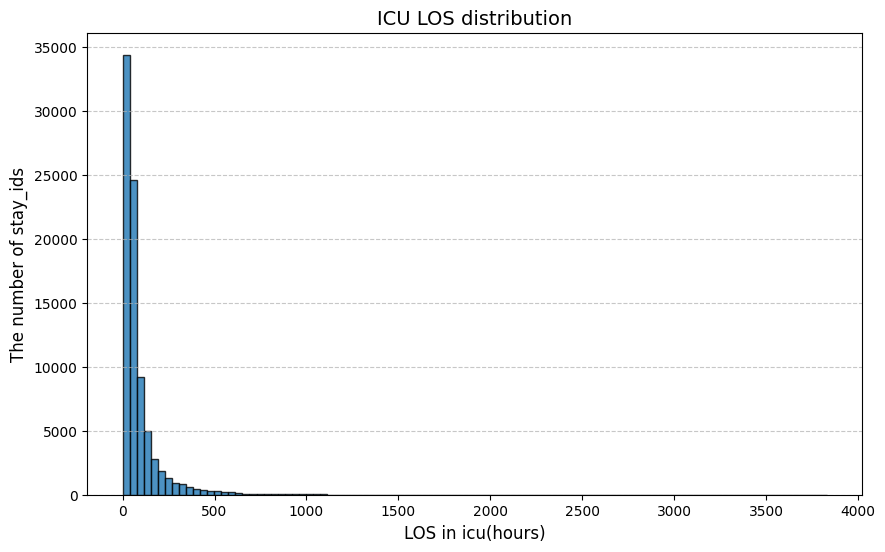

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.hist(updated_df_icustays['los_hours'], bins=100, edgecolor='black', alpha=0.8)
# plt.xlabel('LOS in icu(hours)', fontsize=12)
# plt.ylabel('The number of stay_ids', fontsize=12)
# plt.title('ICU LOS distribution', fontsize=14)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()

In [ ]:
# print("상위 90%: ", np.percentile(updated_df_icustays['los_hours'], 90))
# print("상위 95%: ", np.percentile(updated_df_icustays['los_hours'], 95))
# print("상위 99%: ", np.percentile(updated_df_icustays['los_hours'], 99))

상위 90%:  187.72375
상위 95%:  297.2409027777778
상위 99%:  621.662958333333


In [ ]:
# print("check: ", len(updated_df_icustays[updated_df_icustays['los_hours'] > 1000]))

check:  199


In [6]:
def create_dynamic_hr_timeslots(icustays_df, freq_minutes=60): 
    time_slots_list = []

    for idx, row in icustays_df.iterrows():
        subject_id = row['subject_id']
        hadm_id = row['hadm_id']
        stay_id = row['stay_id']
        intime = row['intime']
        outtime = row['outtime']

        slot_idx = 0
        slot_start = intime
        delta = pd.Timedelta(minutes=freq_minutes)

        while slot_start < outtime: 
            slot_end = slot_start + delta

            time_slots_list.append({
                'subject_id': subject_id,
                'hadm_id': hadm_id,
                'stay_id': stay_id,
                'slot_idx': slot_idx,
                'slot_start': slot_start,
                'slot_end': slot_end
            })

            slot_idx += 1
            slot_start = slot_end

    time_slots_df = pd.DataFrame(time_slots_list)

    time_slots_df['subject_id'] = time_slots_df['subject_id'].astype(int)
    time_slots_df['hadm_id'] = time_slots_df['hadm_id'].astype(int)
    time_slots_df['stay_id'] = time_slots_df['stay_id'].astype(int)

    return time_slots_df

In [7]:
time_slots_df = create_dynamic_hr_timeslots(key_id_icu, freq_minutes=60)
time_slots_df

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end
0,10000032,29079034,39553978,0,2180-07-23 14:00:00,2180-07-23 15:00:00
1,10000032,29079034,39553978,1,2180-07-23 15:00:00,2180-07-23 16:00:00
2,10000032,29079034,39553978,2,2180-07-23 16:00:00,2180-07-23 17:00:00
3,10000032,29079034,39553978,3,2180-07-23 17:00:00,2180-07-23 18:00:00
4,10000032,29079034,39553978,4,2180-07-23 18:00:00,2180-07-23 19:00:00
...,...,...,...,...,...,...
7271435,19999987,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00
7271436,19999987,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00
7271437,19999987,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00
7271438,19999987,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00


In [8]:
time_slots_df['stay_id'].nunique()

84206

In [9]:
time_slots_df[time_slots_df['stay_id']==37086676]

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end
28659,10037483,26819958,37086676,0,2161-08-03 10:33:00,2161-08-03 11:33:00
28660,10037483,26819958,37086676,1,2161-08-03 11:33:00,2161-08-03 12:33:00
28661,10037483,26819958,37086676,2,2161-08-03 12:33:00,2161-08-03 13:33:00
28662,10037483,26819958,37086676,3,2161-08-03 13:33:00,2161-08-03 14:33:00
28663,10037483,26819958,37086676,4,2161-08-03 14:33:00,2161-08-03 15:33:00
...,...,...,...,...,...,...
28859,10037483,26819958,37086676,200,2161-08-11 18:33:00,2161-08-11 19:33:00
28860,10037483,26819958,37086676,201,2161-08-11 19:33:00,2161-08-11 20:33:00
28861,10037483,26819958,37086676,202,2161-08-11 20:33:00,2161-08-11 21:33:00
28862,10037483,26819958,37086676,203,2161-08-11 21:33:00,2161-08-11 22:33:00


---

## 4.1 Procedure events

In [10]:
# # ekg
# proc_itemid = [225402, 225794]

In [11]:
# proc_list = df_ditems[df_ditems['itemid'].isin(proc_itemid)].reset_index(drop=True)
# proc_list

In [12]:
# def resampling_procedure(procedureevents, time_slots_df):

#     """
#     Procedure event를 proc_itemid를 한정하여 resampling함.
#     이때 procedure이 시행되었는지 여부를 0, 1로 라벨링함.
#     """

#     procedureevents = procedureevents[procedureevents['itemid'].isin(proc_itemid)]

#     procedureevents = procedureevents.drop(columns=['valueuom', 'patientweight'])
#     procedureevents = procedureevents.sort_values(by=['stay_id', 'itemid', 'starttime']).reset_index(drop=True)

#     binary_results = []

#     # Binary 처리
#     for idx, row in tqdm(procedureevents.iterrows(), total=len(procedureevents), desc="Processing procedureevents"):
#         hadm = row['hadm_id']
#         stay = row['stay_id']
#         start_time = row['starttime']
#         end_time = row['endtime']
#         itemid = row['itemid']

#         patient_slots = time_slots_df[time_slots_df['stay_id'] == stay].copy()

#         overlapping = patient_slots[
#             (patient_slots['slot_start'] <= end_time) &
#             (patient_slots['slot_end'] > start_time)]
        
#         if overlapping.empty:
#             continue

#         for idx, slotrow in overlapping.iterrows(): 
#             binary_results.append({
#                 'hadm_id': hadm,
#                 'stay_id': stay,
#                 'itemid': itemid,
#                 'hour_slot': slotrow['hour_slot'],
#                 'slot_start': slotrow['slot_start'],
#                 'procedure_flag': 1
#             })

#     binary_results = pd.DataFrame(binary_results).drop_duplicates()
#     expanded_results = []

#     for itemid in tqdm(proc_itemid, total = len(proc_itemid), desc = "Processing procedureevents"):
#         item_slots = time_slots_df.copy()
#         item_slots['itemid'] = itemid
#         item_slots['procedure_flag'] = 0

#         item_data = binary_results[binary_results['itemid']==itemid]
        
#         if not item_data.empty:
#             item_slots = pd.merge(item_slots, item_data[['stay_id', 'hour_slot', 'procedure_flag']], how='left', on=['stay_id', 'hour_slot'])
#             item_slots['procedure_flag'] = item_slots['procedure_flag_y'].fillna(item_slots['procedure_flag_x']).astype(int)
#             item_slots = item_slots.drop(columns=['procedure_flag_x', 'procedure_flag_y'])
#         expanded_results.append(item_slots)

#     processed_df = pd.concat(expanded_results, ignore_index=True)
#     return processed_df

In [13]:
# sequential_df_proc = resampling_procedure(df_proc, time_slots_df)
# sequential_df_proc

In [14]:
# df_proc[(df_proc['itemid']==225794) & (df_proc['stay_id']==37510196)]

In [15]:
# sequential_df_proc[(sequential_df_proc['itemid']==225794) & (sequential_df_proc['stay_id']==37510196)].iloc[35:50, :]

In [16]:
# sequential_df_proc['procedure_flag'].value_counts()

In [17]:
# sequential_df_proc.to_feather(store_dir + '/processed/sequential_df_proc.ftr')

## 4.2 Medication(Inputevents)

- starttime과 endtime이 동일한 Bolus 확인해보기

In [18]:
# # furosemide 250/50 -> furosemide로 통일
# df_input.loc[df_input['itemid']==228340, 'itemid'] = 221794

In [19]:
# # medication에서는 albumin (220862) 삭제, bumetanide, angiotensin도 삭제 -> chartevent에서 활용함
# med_itemid = [221794, 221906, 221662, 221653, 221749, 221986, 222051, 222056, 225168, 225974] 

In [20]:
# med_list = df_ditems[df_ditems['itemid'].isin(med_itemid)].reset_index(drop=True)
# med_list

In [21]:
# # inputevents resampling
# def resampling_input(inputevents, time_slots_df): 
#     """
#     input event를 proc_itemid를 한정하여 resampling함.
#     투여량을 시간에 비례하여 분할하여 같은 itemid끼리는 합산하여 시간당 투여량을 계산함.
#     """

#     inputevents = inputevents[inputevents['itemid'].isin(med_itemid)]
#     inputevents = inputevents.drop(columns=['rate', 'rateuom', 'patientweight'])
#     inputevents = inputevents.sort_values(by=['stay_id', 'itemid', 'starttime']).reset_index(drop=True)

#     expanded_results = []

#     for itemid in tqdm(med_itemid, total=len(med_itemid), desc="Processing inputevents"): 
#         item_slots = time_slots_df.copy()
#         item_slots['itemid'] = itemid
#         item_slots['input_amount'] = np.nan

#         item_data = inputevents[inputevents['itemid'] == itemid]

#         records = []

#         for _, row in item_data.iterrows():
#             stay = row['stay_id']
#             start_time = row['starttime']
#             end_time = row['endtime']
#             amount = row['amount']

#             patient_slots = time_slots_df[time_slots_df['stay_id']==stay].copy()
#             overlapping = patient_slots[(patient_slots['slot_start'] <= end_time) & (patient_slots['slot_end'] > start_time)]
            
#             if overlapping.empty:
#                 continue
            
#             total_hours = (end_time - start_time).total_seconds() / 3600.0

#             if total_hours < 0: 
#                 continue

#             for _, slotrow in overlapping.iterrows(): 
#                 if total_hours == 0:
#                     # Bolus
#                     amount_per_slot = amount

#                 else: 
#                     # Continuous infusion
#                     overlap_start = max(start_time, slotrow['slot_start'])
#                     overlap_end = min(end_time, slotrow['slot_end'])

#                     hours_in_slot = (overlap_end - overlap_start).total_seconds() / 3600.0
#                     hours_in_slot = max(0, hours_in_slot)

#                     amount_per_slot = amount * (hours_in_slot / total_hours)

#                 records.append({
#                     'stay_id': stay,
#                     'hour_slot': slotrow['hour_slot'],
#                     'input_amount': amount_per_slot
#                 })

#         if records:
#             item_data_df = pd.DataFrame(records)
#             grouped_item = item_data_df.groupby(['stay_id', 'hour_slot'], as_index=False)['input_amount'].sum()
    
#             item_slots = pd.merge(item_slots, grouped_item, how='left', on=['stay_id', 'hour_slot'])

#             item_slots['input_amount'] = item_slots['input_amount_y'].combine_first(item_slots['input_amount_x'])
#             item_slots = item_slots.drop(columns=['input_amount_x', 'input_amount_y'])

#         expanded_results.append(item_slots)

#     processed_df = pd.concat(expanded_results, ignore_index=True)
#     return processed_df

In [22]:
# sequential_df_med = resampling_input(df_input, time_slots_df)
# sequential_df_med

In [23]:
# sequential_df_med.to_feather(store_dir + '/processed/sequential_df_med.ftr')

In [24]:
fluid_only_dict = {
    # 'fluid_alb': my_query_dict['fluid_alb'],
    'fluid_cyst': my_query_dict['fluid_cyst']
}

def resampling_fluid(inputevents, time_slots_df, fluid_dict): 
    """
    fluid_dict에 정의된 카테고리(fluid_alb, fluid_cyst)를 기준으로
    해당 카테고리에 속하는 여러 itemid의 투여량을 묶어서 시간대별로 합산하고 빈도를 계산함.
    """
    
    item_to_category = {}
    for category, item_ids in fluid_dict.items():
        for itemid in item_ids:
            item_to_category[itemid] = category
            
    # 매핑된 itemid에 해당하는 데이터만 필터링
    fluid_events = inputevents[inputevents['itemid'].isin(item_to_category.keys())].copy()
    fluid_events['fluid_category'] = fluid_events['itemid'].map(item_to_category)

    fluid_events = fluid_events[fluid_events['amount'] > 0]
    fluid_events = fluid_events.drop(columns=['rate', 'rateuom', 'patientweight'], errors='ignore')
    fluid_events = fluid_events.sort_values(by=['stay_id', 'fluid_category', 'starttime']).reset_index(drop=True)

    expanded_results = []
    categories = list(fluid_dict.keys())
    chunk_size = 3000
    
    for cat in tqdm(categories, total=len(categories), desc="Processing fluid categories"): 
        cat_data = fluid_events[fluid_events['fluid_category'] == cat]

        unique_stays = cat_data['stay_id'].unique()
        all_grouped_chunks = []

        for i in tqdm(range(0, len(unique_stays), chunk_size), desc=f"Chunking {cat}", leave=False):
            chunk_stays = unique_stays[i : i + chunk_size]

            cat_chunk = cat_data[cat_data['stay_id'].isin(chunk_stays)]
            slot_chunk = time_slots_df[time_slots_df['stay_id'].isin(chunk_stays)]

            merged = pd.merge(cat_chunk, slot_chunk, on='stay_id', how='inner')
                
            # 시간이 겹치는 구간만 남기고 필터링
            mask = (merged['slot_start'] <= merged['endtime']) & (merged['slot_end'] >= merged['starttime'])
            valid = merged[mask].copy()
            del merged
        
            # 각 투여 기록의 총 투여 시간 계산
            valid['total_hours'] = (valid['endtime'] - valid['starttime']).dt.total_seconds() / 3600.0
            valid = valid[valid['total_hours'] >= 0]
        
            # 겹치는 시간 계산
            overlap_start = np.maximum(valid['starttime'], valid['slot_start'])
            overlap_end = np.minimum(valid['endtime'], valid['slot_end'])
        
            valid['hours_in_slot'] = (overlap_end - overlap_start).dt.total_seconds() / 3600.0
            valid['hours_in_slot'] = valid['hours_in_slot'].clip(lower=0) # 음수 방지
        
            # 투여량 분할 계산
            is_bolus = valid['total_hours'] == 0
            is_bolus_in_slot = is_bolus & (valid['starttime'] >= valid['slot_start']) & (valid['starttime'] < valid['slot_end'])

            valid['amount_per_slot'] = np.where(
                is_bolus,
                np.where(is_bolus_in_slot, valid['amount'], 0),
                valid['amount'] * (valid['hours_in_slot'] / valid['total_hours']) # Continuous
            )

            # [추가 1] 해당 슬롯에 실질적으로 0 초과의 수액이 투여된 기록만 필터링 (가짜 중복 카운트 방지)
            valid = valid[valid['amount_per_slot'] > 0].copy()

            valid['is_decision_point'] = (
                ((valid['starttime'] >= valid['slot_start']) & (valid['starttime'] < valid['slot_end'])) |
                ((valid['endtime'] > valid['slot_start']) & (valid['endtime'] <= valid['slot_end']))
            )

            # [수정] sum() 대신 agg()를 사용하여 투여량 합산과 투여 결정 횟수(count) 계산
            grouped_chunk = valid.groupby(['stay_id', 'slot_idx'], as_index=False).agg(
                input_amount=('amount_per_slot', 'sum'),
                input_count=('is_decision_point', 'sum') # 단순 row count가 아닌, 이벤트 발생 여부의 합
            )
            
            all_grouped_chunks.append(grouped_chunk)

            del valid, cat_chunk, slot_chunk

        if all_grouped_chunks:
            grouped = pd.concat(all_grouped_chunks, ignore_index=True)
        else:
            # [수정 2] 빈 데이터프레임 생성 시 input_count 컬럼 추가
            grouped = pd.DataFrame(columns=['stay_id', 'slot_idx', 'input_amount', 'input_count'])
            
        # agg()에서 이미 'input_amount'로 이름을 지정했으므로 rename 코드는 삭제합니다.
        # grouped.rename(columns={'amount_per_slot': 'input_amount'}, inplace=True) <- 삭제됨
        
        # 최종 병합
        item_slots = time_slots_df.copy()
        item_slots['fluid_category'] = cat
        item_slots = pd.merge(item_slots, grouped, how='left', on=['stay_id', 'slot_idx'])
        
        # [추가/수정 3] 결측치(투여 없는 구간) 0으로 채우기
        item_slots['input_amount'] = item_slots['input_amount'].fillna(0)
        item_slots['input_count'] = item_slots['input_count'].fillna(0).astype(int)

        expanded_results.append(item_slots)

    processed_df = pd.concat(expanded_results, ignore_index=True)
    return processed_df

In [25]:
sequential_df_fluid = resampling_fluid(df_input, time_slots_df, fluid_only_dict)
sequential_df_fluid

Processing fluid categories:   0%|          | 0/1 [00:00<?, ?it/s]

Chunking fluid_cyst:   0%|          | 0/28 [00:00<?, ?it/s]

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,fluid_category,input_amount,input_count
0,10000032,29079034,39553978,0,2180-07-23 14:00:00,2180-07-23 15:00:00,fluid_cyst,0.0,0
1,10000032,29079034,39553978,1,2180-07-23 15:00:00,2180-07-23 16:00:00,fluid_cyst,0.0,0
2,10000032,29079034,39553978,2,2180-07-23 16:00:00,2180-07-23 17:00:00,fluid_cyst,0.0,0
3,10000032,29079034,39553978,3,2180-07-23 17:00:00,2180-07-23 18:00:00,fluid_cyst,200.0,1
4,10000032,29079034,39553978,4,2180-07-23 18:00:00,2180-07-23 19:00:00,fluid_cyst,100.0,1
...,...,...,...,...,...,...,...,...,...
7271435,19999987,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,fluid_cyst,0.0,0
7271436,19999987,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,fluid_cyst,0.0,0
7271437,19999987,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,fluid_cyst,0.0,0
7271438,19999987,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,fluid_cyst,201.2,2


In [26]:
sequential_df_fluid.to_feather(store_dir + 'full_sequential_df_fluid.ftr')

## SBP, DBP, MAP

In [27]:
key_ids = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]
df_bp = key_ids.merge(df_sbpdbp, how='left', on=['subject_id', 'hadm_id', 'stay_id'])
df_bp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp,map
0,10000032,29079034,39553978,2180-07-23 14:11:00,84.0,48.0,56.000000
1,10000032,29079034,39553978,2180-07-23 14:30:00,95.0,59.0,67.000000
2,10000032,29079034,39553978,2180-07-23 15:00:00,88.0,56.0,64.000000
3,10000032,29079034,39553978,2180-07-23 16:01:00,91.0,55.0,64.000000
4,10000032,29079034,39553978,2180-07-23 17:00:00,95.0,58.0,67.000000
...,...,...,...,...,...,...,...
7534888,19999987,23865745,36195440,2145-11-04 09:00:00,117.0,52.0,60.000000
7534889,19999987,23865745,36195440,2145-11-04 13:48:00,121.0,72.0,84.000000
7534890,19999987,23865745,36195440,2145-11-04 16:53:00,152.0,92.0,102.000000
7534891,19999987,23865745,36195440,2145-11-04 19:31:00,163.0,120.0,134.333333


In [28]:
df_bp.isnull().sum()

subject_id      0
hadm_id         0
stay_id         0
charttime     203
sbp           203
dbp           203
map           203
dtype: int64

In [29]:
# 혈압을 아예 측정하지 않은 stay_id가 72행 존재함.
df_bp[df_bp['charttime'].isna()]

,subject_id,hadm_id,stay_id,charttime,sbp,dbp,map
309326,10421309,27692702,30336793,NaT,NaN,NaN,NaN
335053,10459005,23791208,36888345,NaT,NaN,NaN,NaN
335339,10459005,25159727,33128048,NaT,NaN,NaN,NaN
389936,10537300,22180541,31778631,NaT,NaN,NaN,NaN
401131,10554954,25755212,31330872,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...
7349378,19759225,27946419,38757839,NaT,NaN,NaN,NaN
7467933,19914761,22798274,31650349,NaT,NaN,NaN,NaN
7506091,19966756,21810863,35386597,NaT,NaN,NaN,NaN
7506092,19966756,25743475,31524635,NaT,NaN,NaN,NaN


In [30]:
df_bp = df_bp.dropna(subset=['charttime']).reset_index(drop=True)

In [31]:
df_bp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp,map
0,10000032,29079034,39553978,2180-07-23 14:11:00,84.0,48.0,56.000000
1,10000032,29079034,39553978,2180-07-23 14:30:00,95.0,59.0,67.000000
2,10000032,29079034,39553978,2180-07-23 15:00:00,88.0,56.0,64.000000
3,10000032,29079034,39553978,2180-07-23 16:01:00,91.0,55.0,64.000000
4,10000032,29079034,39553978,2180-07-23 17:00:00,95.0,58.0,67.000000
...,...,...,...,...,...,...,...
7534685,19999987,23865745,36195440,2145-11-04 09:00:00,117.0,52.0,60.000000
7534686,19999987,23865745,36195440,2145-11-04 13:48:00,121.0,72.0,84.000000
7534687,19999987,23865745,36195440,2145-11-04 16:53:00,152.0,92.0,102.000000
7534688,19999987,23865745,36195440,2145-11-04 19:31:00,163.0,120.0,134.333333


In [32]:
def resampling_bp(df_bp, time_slots_df, agg_method='mean'):
    df_bp = df_bp.copy()

    df_bp = df_bp.dropna(subset=['stay_id', 'charttime'])

    df_bp['stay_id'] = df_bp['stay_id'].astype('int')
    df_bp['charttime'] = pd.to_datetime(df_bp['charttime'])

    time_slots = time_slots_df.copy()
    time_slots['stay_id'] = time_slots['stay_id'].astype('int')
    time_slots['slot_start'] = pd.to_datetime(time_slots['slot_start'])

    df_bp = df_bp.sort_values(by=['charttime']).reset_index(drop=True)
    time_slots = time_slots.sort_values(by=['slot_start']).reset_index(drop=True)

    # 혈압 측정 시간(charttime)을 기준으로 가장 가까운 과거의 타임슬롯(slot_start)에 매핑
    merged = pd.merge_asof(
        df_bp,
        time_slots[['stay_id', 'slot_idx', 'slot_start', 'slot_end']],
        by='stay_id',
        left_on='charttime',
        right_on='slot_start',
        direction='backward'
    )

    merged = merged.dropna(subset=['slot_start']) # 타임슬롯 이전의 과거 데이터 제외
    mask = (merged['charttime'] >= merged['slot_start']) & (merged['charttime'] < merged['slot_end'])
    valid = merged[mask].copy()

    agg_func = 'mean' if agg_method == 'mean' else 'last'

    sbp_col = f'sbp_{agg_func}'
    dbp_col = f'dbp_{agg_func}'
    map_col = f'map_{agg_func}'

    # 동일한 환자(stay_id)의 동일한 30분 슬롯(slot_idx) 내 측정값 평균 계산
    grouped = valid.groupby(['stay_id', 'slot_idx', 'slot_start'], as_index=False).agg(**{
        sbp_col: ('sbp', agg_func),
        dbp_col: ('dbp', agg_func),
        map_col: ('map', agg_func),
        'bp_count': ('sbp', 'count'),
        'actual_time': ('charttime', 'max') # 실제 측정 시간은 기조와 상관없이 max 보존
    })

    grouped = grouped[grouped[sbp_col] > grouped[dbp_col]].reset_index(drop=True)

    # 원본 time_slots_df에 최종 Left Join
    # 혈압 측정이 없었던 구간은 NaN
    final_result = pd.merge(
        time_slots,
        grouped,
        on=['stay_id', 'slot_idx', 'slot_start'],
        how='left'
    )

    final_result['bp_count'] = final_result['bp_count'].fillna(0).astype(int)

    return final_result.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)

In [33]:
df_resampled_bp = resampling_bp(df_bp, time_slots_df, agg_method='last')
# df_resampled_bp = df_resampled_bp.rename(columns={'sbp_mean':'sbp', 'dbp_mean':'dbp', 'map_mean':'map'})
df_resampled_bp = df_resampled_bp.rename(columns={'sbp_last':'sbp', 'dbp_last':'dbp', 'map_last':'map'})
df_resampled_bp

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,sbp,dbp,map,bp_count,actual_time
0,12466550,23998182,30000153,0,2174-09-29 12:09:00,2174-09-29 13:09:00,113.0,77.0,84.0,1,2174-09-29 13:00:00
1,12466550,23998182,30000153,1,2174-09-29 13:09:00,2174-09-29 14:09:00,131.0,61.0,80.0,2,2174-09-29 14:00:00
2,12466550,23998182,30000153,2,2174-09-29 14:09:00,2174-09-29 15:09:00,NaN,NaN,NaN,0,NaT
3,12466550,23998182,30000153,3,2174-09-29 15:09:00,2174-09-29 16:09:00,109.0,55.0,71.0,2,2174-09-29 16:00:00
4,12466550,23998182,30000153,4,2174-09-29 16:09:00,2174-09-29 17:09:00,111.0,56.0,71.0,1,2174-09-29 17:00:00
...,...,...,...,...,...,...,...,...,...,...,...
7271435,10826461,26489824,39999858,89,2167-04-30 05:36:00,2167-04-30 06:36:00,NaN,NaN,NaN,0,NaT
7271436,10826461,26489824,39999858,90,2167-04-30 06:36:00,2167-04-30 07:36:00,NaN,NaN,NaN,0,NaT
7271437,10826461,26489824,39999858,91,2167-04-30 07:36:00,2167-04-30 08:36:00,NaN,NaN,NaN,0,NaT
7271438,10826461,26489824,39999858,92,2167-04-30 08:36:00,2167-04-30 09:36:00,NaN,NaN,NaN,0,NaT


In [34]:
df_resampled_bp['bp_count'].max()

60

In [ ]:
df_resampled_bp.to_feather(store_dir + 'full_sequential_df_bp.ftr')

## 4.3 Chart events

- GCS는 별도로 처리해야 함

In [36]:
gcs_itemids = {220739, 223900, 223901}

gcs_raw = df_chart[df_chart['itemid'].isin(gcs_itemids)].copy()

gcs_grouped = gcs_raw.groupby(['stay_id', 'charttime'], as_index=False).agg(
    valuenum=('valuenum', 'sum'),
    component_count=('itemid', 'count') # 몇 개의 컴포넌트가 기록되었는지 카운트
)

# 3가지(Eye, Verbal, Motor)가 모두 기록된 시간대의 데이터만 유효한 GCS로 인정
gcs_valid = gcs_grouped[gcs_grouped['component_count'] == 3].copy()

gcs_valid['feature_name'] = 'gcs'
gcs_valid = gcs_valid[['stay_id', 'feature_name', 'charttime', 'valuenum']]

In [37]:
gcs_valid

,stay_id,feature_name,charttime,valuenum
0,30000153,gcs,2174-09-29 12:45:00,9.0
1,30000153,gcs,2174-09-29 16:26:00,11.0
2,30000153,gcs,2174-09-29 17:37:00,11.0
3,30000153,gcs,2174-09-29 18:00:00,9.0
4,30000153,gcs,2174-09-29 19:00:00,9.0
...,...,...,...,...
1977191,39999858,gcs,2167-04-29 20:00:00,15.0
1977192,39999858,gcs,2167-04-30 00:00:00,15.0
1977193,39999858,gcs,2167-04-30 04:00:00,15.0
1977194,39999858,gcs,2167-04-30 07:00:00,15.0


In [38]:
# BNP는 일단 포함은 시켜보자고
exclude_vars = {'specimen', 'height', 'weight', 'sbp', 'dbp', 'map', 'NTproBNP', 'ck_mb_frac', 'gcs', 'fluid_alb', 'fluid_cyst', 'urine'}

itemid_to_var_name = {itemid: var_name for var_name, ids in my_query_dict.items() for itemid in ids if var_name not in exclude_vars}

In [39]:
print(itemid_to_var_name)

{220045: 'heart_rate', 50825: 'temperature', 223761: 'temperature', 223762: 'temperature', 224690: 'resp_rate', 220210: 'resp_rate', 50817: 'o2sat', 220277: 'o2sat', 220227: 'o2sat', 50821: 'pao2', 220224: 'pao2', 50816: 'fio2', 223835: 'fio2', 50818: 'paco2', 52040: 'paco2', 220235: 'paco2', 51300: 'wbc', 51301: 'wbc', 51755: 'wbc', 51756: 'wbc', 220546: 'wbc', 51265: 'platelets', 51704: 'platelets', 227457: 'platelets', 51221: 'hematocrit', 51638: 'hematocrit', 51639: 'hematocrit', 52028: 'hematocrit', 50810: 'hematocrit', 226540: 'hematocrit', 220545: 'hematocrit', 50811: 'hemoglobin', 51222: 'hemoglobin', 51640: 'hemoglobin', 220228: 'hemoglobin', 51237: 'pt_inr', 51675: 'pt_inr', 227467: 'pt_inr', 51275: 'ptt', 52923: 'ptt', 227466: 'ptt', 52551: 'd-dimer', 51196: 'd-dimer', 50915: 'd-dimer', 225636: 'd-dimer', 50983: 'sodium', 52623: 'sodium', 50824: 'sodium', 52455: 'sodium', 220645: 'sodium', 228389: 'sodium', 226534: 'sodium', 228390: 'sodium', 50971: 'potassium', 52610: 'pota

In [40]:
bakcup_df_lab = df_lab.copy()
bakcup_df_chart = df_chart.copy()

In [41]:
# ICU 입실 전 Lab 데이터 추출

def get_ward_lab_before_icu_admission(df_lab, time_slots_df, itemid_to_var_name):
    valid_itemids = set(itemid_to_var_name.keys())
    df_lab = df_lab[df_lab['itemid'].isin(valid_itemids)].copy()

    icu_start_df = time_slots_df[time_slots_df['slot_idx'] == 0][['stay_id', 'hadm_id', 'slot_start']]
    df_lab = df_lab.merge(icu_start_df, on='hadm_id', how='inner')
    
    df_lab = df_lab[
        (df_lab['charttime'] >= df_lab['slot_start'] - pd.Timedelta(hours=24)) &
        (df_lab['charttime'] < df_lab['slot_start'])
    ].copy()
    
    df_lab['feature_name'] = df_lab['itemid'].map(itemid_to_var_name)
    df_lab['time_diff'] = (df_lab['slot_start'] - df_lab['charttime']).abs()
    
    # ICU T=0 slot으로 할당할 값 남기기
    closest = df_lab.loc[df_lab.groupby(['stay_id', 'feature_name'])['time_diff'].idxmin()].copy()
    closest['slot_idx'] = 0

    return closest[['stay_id', 'feature_name', 'slot_idx', 'slot_start', 'valuenum']].rename(columns={'valuenum': 'value'})

In [42]:
df_ward_T0 = get_ward_lab_before_icu_admission(df_lab, time_slots_df, itemid_to_var_name)
df_ward_T0

,stay_id,feature_name,slot_idx,slot_start,value
6327938,30000213,art_ph,0,2162-06-21 05:38:00,7.37
6327935,30000213,base_excess,0,2162-06-21 05:38:00,0.00
6327936,30000213,o2sat,0,2162-06-21 05:38:00,93.00
6327937,30000213,paco2,0,2162-06-21 05:38:00,42.00
6327939,30000213,pao2,0,2162-06-21 05:38:00,79.00
...,...,...,...,...,...
10704890,39999562,hemoglobin,0,2129-01-24 17:24:09,9.60
10704891,39999562,platelets,0,2129-01-24 17:24:09,141.00
10704886,39999562,potassium,0,2129-01-24 17:24:09,3.90
10704887,39999562,sodium,0,2129-01-24 17:24:09,140.00


In [43]:
def assign_stayid_to_lab(df_lab, time_slots_df, itemid_to_var_name):
    valid_itemids = set(itemid_to_var_name.keys())
    df_lab = df_lab[df_lab['itemid'].isin(valid_itemids)].copy()
    
    df_lab['feature_name'] = df_lab['itemid'].map(itemid_to_var_name)

    icu_min_time = time_slots_df['slot_start'].min()
    df_lab = df_lab[df_lab['charttime'] >= icu_min_time].copy()

    icu_stay_ranges = time_slots_df.groupby(['stay_id', 'hadm_id'], as_index=False).agg(
        intime=('slot_start', 'min'),
        outtime=('slot_end', 'max')
    )

    merged_lab = pd.merge(df_lab, icu_stay_ranges, on='hadm_id', how='inner')

    mask = (merged_lab['charttime'] >= merged_lab['intime']) & (merged_lab['charttime'] < merged_lab['outtime'])
    valid_lab = merged_lab[mask].copy()

    valid_lab = valid_lab.drop(columns=['intime', 'outtime'])

    return valid_lab

In [44]:
# ICU 기간 동안의 Lab 데이터만 필터링하고 stay_id를 할당함.
stayid_with_lab = assign_stayid_to_lab(df_lab, time_slots_df, itemid_to_var_name)
stayid_with_lab

,subject_id,hadm_id,specimen_id,itemid,charttime,valuenum,valueuom,feature_name,stay_id
1,10000032.0,29079034.0,55621508,50868,2180-07-23 21:45:00,14.0,mEq/L,anion_gap,39553978
2,10000032.0,29079034.0,55621508,50912,2180-07-23 21:45:00,0.5,mg/dL,creatinine,39553978
3,10000032.0,29079034.0,55621508,50931,2180-07-23 21:45:00,115.0,mg/dL,glucose,39553978
4,10000032.0,29079034.0,55621508,50971,2180-07-23 21:45:00,4.7,mEq/L,potassium,39553978
5,10000032.0,29079034.0,55621508,50983,2180-07-23 21:45:00,132.0,mEq/L,sodium,39553978
...,...,...,...,...,...,...,...,...,...
19678702,19999987.0,23865745.0,70437837,50821,2145-11-04 07:18:00,69.0,mm Hg,pao2,36195440
19678703,19999987.0,23865745.0,56350925,51221,2145-11-04 10:40:00,38.2,%,hematocrit,36195440
19678704,19999987.0,23865745.0,56350925,51222,2145-11-04 10:40:00,12.6,g/dL,hemoglobin,36195440
19678705,19999987.0,23865745.0,56350925,51265,2145-11-04 10:40:00,120.0,K/uL,platelets,36195440


In [45]:
valid_itemids = set(itemid_to_var_name.keys())
df_chart_valid = df_chart[df_chart['itemid'].isin(valid_itemids)].copy()
df_chart_valid['feature_name'] = df_chart_valid['itemid'].map(itemid_to_var_name)

In [46]:
cols_to_keep = ['stay_id', 'feature_name', 'charttime', 'valuenum']
icu_lab_sub = stayid_with_lab[cols_to_keep]
icu_chart_sub = df_chart_valid[cols_to_keep]

# GCS 합쳐주기
icu_chart_sub = pd.concat([icu_chart_sub, gcs_valid], ignore_index=True)

combined_raw = pd.concat([icu_chart_sub, icu_lab_sub], ignore_index=True)

# 완전히 동일한 시간에 측정된 중복값 제거
# (예: 동일한 10:00에 Lab과 Chart에 모두 기록된 경우 하나만 남김)
deduplicated_raw = combined_raw.drop_duplicates(
    subset=['stay_id', 'feature_name', 'charttime'], 
    keep='last'
)

In [47]:
len(icu_lab_sub) + len(icu_chart_sub)

48807355

In [48]:
deduplicated_raw

,stay_id,feature_name,charttime,valuenum
0,39553978,temperature,2180-07-23 14:00:00,37.055556
1,39553978,heart_rate,2180-07-23 14:12:00,91.000000
2,39553978,resp_rate,2180-07-23 14:12:00,24.000000
3,39553978,o2sat,2180-07-23 14:13:00,98.000000
4,39553978,heart_rate,2180-07-23 14:30:00,93.000000
...,...,...,...,...
48807350,36195440,pao2,2145-11-04 07:18:00,69.000000
48807351,36195440,hematocrit,2145-11-04 10:40:00,38.200000
48807352,36195440,hemoglobin,2145-11-04 10:40:00,12.600000
48807353,36195440,platelets,2145-11-04 10:40:00,120.000000


In [49]:
itemid_to_var_name

{220045: 'heart_rate',
 50825: 'temperature',
 223761: 'temperature',
 223762: 'temperature',
 224690: 'resp_rate',
 220210: 'resp_rate',
 50817: 'o2sat',
 220277: 'o2sat',
 220227: 'o2sat',
 50821: 'pao2',
 220224: 'pao2',
 50816: 'fio2',
 223835: 'fio2',
 50818: 'paco2',
 52040: 'paco2',
 220235: 'paco2',
 51300: 'wbc',
 51301: 'wbc',
 51755: 'wbc',
 51756: 'wbc',
 220546: 'wbc',
 51265: 'platelets',
 51704: 'platelets',
 227457: 'platelets',
 51221: 'hematocrit',
 51638: 'hematocrit',
 51639: 'hematocrit',
 52028: 'hematocrit',
 50810: 'hematocrit',
 226540: 'hematocrit',
 220545: 'hematocrit',
 50811: 'hemoglobin',
 51222: 'hemoglobin',
 51640: 'hemoglobin',
 220228: 'hemoglobin',
 51237: 'pt_inr',
 51675: 'pt_inr',
 227467: 'pt_inr',
 51275: 'ptt',
 52923: 'ptt',
 227466: 'ptt',
 52551: 'd-dimer',
 51196: 'd-dimer',
 50915: 'd-dimer',
 225636: 'd-dimer',
 50983: 'sodium',
 52623: 'sodium',
 50824: 'sodium',
 52455: 'sodium',
 220645: 'sodium',
 228389: 'sodium',
 226534: 'sodium',

In [50]:
def resampling_chart(combined_df, time_slots_df, agg_method='mean'):
    combined_df = combined_df.dropna(subset=['stay_id', 'charttime']).copy()

    combined_df['stay_id'] = combined_df['stay_id'].astype('int')

    time_slots_df = time_slots_df.copy()
    time_slots_df['stay_id'] = time_slots_df['stay_id'].astype('int')

    # 2. 시간순 정렬 및 As-of Merge 적용
    combined_sorted = combined_df.sort_values('charttime').reset_index(drop=True)
    slots_sorted = time_slots_df.sort_values('slot_start').reset_index(drop=True)

    merged = pd.merge_asof(
        combined_sorted,
        slots_sorted,
        by='stay_id',
        left_on='charttime',
        right_on='slot_start',
        direction='backward'
    )

    merged = merged.dropna(subset=['slot_start'])
    merged = merged[(merged['charttime'] >= merged['slot_start']) & (merged['charttime'] < merged['slot_end'])]

    # 3. 슬롯별 집계 (Aggregation)
    agg_func = 'mean' if agg_method == 'mean' else 'last'

    grouped = (
        merged.groupby(['stay_id', 'feature_name', 'slot_idx', 'slot_start'], as_index=False)
        .agg(
            value=('valuenum', agg_func),
            measure_count=('valuenum', 'count'),
            actual_time=('charttime', 'max') 
        )
    )

    stay_slots = time_slots_df[['stay_id', 'slot_idx', 'slot_start']].drop_duplicates()

    unique_features = merged['feature_name'].unique()
    items_df = pd.DataFrame({'feature_name': unique_features})
    full_slots = stay_slots.merge(items_df, how='cross')

    final_result = pd.merge(
        full_slots, grouped,
        on=['stay_id', 'slot_idx', 'slot_start', 'feature_name'],
        how='left'
    )

    final_result['measure_count'] = final_result['measure_count'].fillna(0).astype(int)

    return final_result.sort_values(['stay_id', 'feature_name', 'slot_start']).reset_index(drop=True)

In [51]:
icu_merged = resampling_chart(
    combined_df=deduplicated_raw, 
    time_slots_df=time_slots_df, 
    agg_method='last'
)

In [52]:
icu_merged[icu_merged['feature_name']=='gcs']

,stay_id,slot_idx,slot_start,feature_name,value,measure_count,actual_time
600,30000153,0,2174-09-29 12:09:00,gcs,9.0,1,2174-09-29 12:45:00
601,30000153,1,2174-09-29 13:09:00,gcs,NaN,0,NaT
602,30000153,2,2174-09-29 14:09:00,gcs,NaN,0,NaT
603,30000153,3,2174-09-29 15:09:00,gcs,NaN,0,NaT
604,30000153,4,2174-09-29 16:09:00,gcs,11.0,1,2174-09-29 16:26:00
...,...,...,...,...,...,...,...
239955917,39999858,89,2167-04-30 05:36:00,gcs,NaN,0,NaT
239955918,39999858,90,2167-04-30 06:36:00,gcs,15.0,1,2167-04-30 07:00:00
239955919,39999858,91,2167-04-30 07:36:00,gcs,15.0,1,2167-04-30 08:00:00
239955920,39999858,92,2167-04-30 08:36:00,gcs,NaN,0,NaT


In [53]:
icu_merged['feature_name'].unique()

array(['Brain Natiuretic Peptide', 'albumin', 'alt', 'anion_gap',
       'art_ph', 'ast', 'base_excess', 'bilirubin', 'bun', 'ca_ion',
       'chloride', 'ck_mb', 'creatinine', 'd-dimer', 'fio2', 'gcs',
       'glucose', 'heart_rate', 'hematocrit', 'hemoglobin', 'lactate',
       'o2sat', 'paco2', 'pao2', 'platelets', 'potassium', 'pt_inr',
       'ptt', 'resp_rate', 'sodium', 'temperature', 'troponin-T', 'wbc'],
      dtype=object)

In [54]:
bnp_df = icu_merged[icu_merged['feature_name']=='Brain Natiuretic Peptide']
bnp_df['measure_count'].value_counts()

measure_count
0    7267657
1       3782
2          1
Name: count, dtype: int64

| 이름          | 내용                                                                 | 생성 방법                        |
|---------------|----------------------------------------------------------------------|----------------------------------|
| `sequential_df_chart`    | ICU stay 중 chart events를 `slot_start` 기준으로 리샘플링한 시계열      | `resampling_chart()`             |
| `df_ward_T0`  | ICU 입실 전 24시간 내 병동 lab 중 가장 최근값을 T=0 slot에 할당         | `get_ward_lab_before_icu_admission()` |
| `df_ward_icu` | ICU stay 중 charttime이 ICU 체류 구간에 포함되는 병동 lab 값을 각 slot에 할당 | `get_ward_lab_within_icu_stay()` |

In [55]:
df_ward_T0_ready = df_ward_T0.rename(columns={'value': 'value_ward', 'slot_start': 'slot_start_ward'}).copy()

final_merged = pd.merge(
    icu_merged, 
    df_ward_T0_ready, 
    on=['stay_id', 'feature_name', 'slot_idx'], 
    how='outer'
)

# 이거 하려고 일부로 slot_start는 Merge의 on 대상에서 제외하였음.
final_merged['slot_start'] = final_merged['slot_start'].fillna(final_merged['slot_start_ward'])

# slot_idx==0이고, ICU value가 결측치일 때만 병동 데이터(value ward)로 채우기
is_ward_fillable = (final_merged['slot_idx'] == 0) & (final_merged['value'].isna()) & (final_merged['value_ward'].notna())

final_merged['value'] = np.where(is_ward_fillable, final_merged['value_ward'], final_merged['value'])

# 병동 데이터를 가져왔으므로 카운트도 1로 보완
final_merged['measure_count'] = np.where(is_ward_fillable, 1, final_merged['measure_count'])
final_merged['measure_count'] = final_merged['measure_count'].fillna(0).astype(int)

final_merged = final_merged.drop(columns=['value_ward', 'slot_start_ward'])
lab_imputed_chart = final_merged.sort_values(['stay_id', 'feature_name', 'slot_idx']).reset_index(drop=True)

In [56]:
lab_imputed_chart['stay_id'].nunique()

84206

In [57]:
lab_imputed_chart

,stay_id,slot_idx,slot_start,feature_name,value,measure_count,actual_time
0,30000153,0,2174-09-29 12:09:00,Brain Natiuretic Peptide,NaN,0,NaT
1,30000153,1,2174-09-29 13:09:00,Brain Natiuretic Peptide,NaN,0,NaT
2,30000153,2,2174-09-29 14:09:00,Brain Natiuretic Peptide,NaN,0,NaT
3,30000153,3,2174-09-29 15:09:00,Brain Natiuretic Peptide,NaN,0,NaT
4,30000153,4,2174-09-29 16:09:00,Brain Natiuretic Peptide,NaN,0,NaT
...,...,...,...,...,...,...,...
239957515,39999858,89,2167-04-30 05:36:00,wbc,NaN,0,NaT
239957516,39999858,90,2167-04-30 06:36:00,wbc,NaN,0,NaT
239957517,39999858,91,2167-04-30 07:36:00,wbc,NaN,0,NaT
239957518,39999858,92,2167-04-30 08:36:00,wbc,NaN,0,NaT


In [58]:
lab_imputed_chart['feature_name'].nunique()

33

In [59]:
lab_imputed_chart['feature_name'].unique()

array(['Brain Natiuretic Peptide', 'albumin', 'alt', 'anion_gap',
       'art_ph', 'ast', 'base_excess', 'bilirubin', 'bun', 'ca_ion',
       'chloride', 'ck_mb', 'creatinine', 'd-dimer', 'fio2', 'gcs',
       'glucose', 'heart_rate', 'hematocrit', 'hemoglobin', 'lactate',
       'o2sat', 'paco2', 'pao2', 'platelets', 'potassium', 'pt_inr',
       'ptt', 'resp_rate', 'sodium', 'temperature', 'troponin-T', 'wbc'],
      dtype=object)

In [60]:
lab_imputed_chart = lab_imputed_chart.drop(columns=['actual_time'])
lab_imputed_chart['value'] = lab_imputed_chart['value'].fillna(0)

In [61]:
lab_imputed_chart

,stay_id,slot_idx,slot_start,feature_name,value,measure_count
0,30000153,0,2174-09-29 12:09:00,Brain Natiuretic Peptide,0.0,0
1,30000153,1,2174-09-29 13:09:00,Brain Natiuretic Peptide,0.0,0
2,30000153,2,2174-09-29 14:09:00,Brain Natiuretic Peptide,0.0,0
3,30000153,3,2174-09-29 15:09:00,Brain Natiuretic Peptide,0.0,0
4,30000153,4,2174-09-29 16:09:00,Brain Natiuretic Peptide,0.0,0
...,...,...,...,...,...,...
239957515,39999858,89,2167-04-30 05:36:00,wbc,0.0,0
239957516,39999858,90,2167-04-30 06:36:00,wbc,0.0,0
239957517,39999858,91,2167-04-30 07:36:00,wbc,0.0,0
239957518,39999858,92,2167-04-30 08:36:00,wbc,0.0,0


In [62]:
# 이게 NaN인 값들임.
lab_imputed_chart[(lab_imputed_chart['value']==0.0) & (lab_imputed_chart['measure_count']==0)]

,stay_id,slot_idx,slot_start,feature_name,value,measure_count
0,30000153,0,2174-09-29 12:09:00,Brain Natiuretic Peptide,0.0,0
1,30000153,1,2174-09-29 13:09:00,Brain Natiuretic Peptide,0.0,0
2,30000153,2,2174-09-29 14:09:00,Brain Natiuretic Peptide,0.0,0
3,30000153,3,2174-09-29 15:09:00,Brain Natiuretic Peptide,0.0,0
4,30000153,4,2174-09-29 16:09:00,Brain Natiuretic Peptide,0.0,0
...,...,...,...,...,...,...
239957515,39999858,89,2167-04-30 05:36:00,wbc,0.0,0
239957516,39999858,90,2167-04-30 06:36:00,wbc,0.0,0
239957517,39999858,91,2167-04-30 07:36:00,wbc,0.0,0
239957518,39999858,92,2167-04-30 08:36:00,wbc,0.0,0


In [63]:
lab_imputed_chart[lab_imputed_chart['value'] > 0.0]

,stay_id,slot_idx,slot_start,feature_name,value,measure_count
112,30000153,32,2174-09-30 20:09:00,alt,15.000000,1
123,30000153,3,2174-09-29 15:09:00,anion_gap,12.000000,1
135,30000153,15,2174-09-30 03:09:00,anion_gap,12.000000,1
161,30000153,1,2174-09-29 13:09:00,art_ph,7.300000,2
163,30000153,3,2174-09-29 15:09:00,art_ph,7.310000,1
...,...,...,...,...,...,...
239957329,39999858,91,2167-04-30 07:36:00,temperature,36.888889,1
239957438,39999858,12,2167-04-27 00:36:00,wbc,6.300000,1
239957463,39999858,37,2167-04-28 01:36:00,wbc,7.100000,1
239957488,39999858,62,2167-04-29 02:36:00,wbc,8.000000,1


In [64]:
lab_imputed_chart.to_feather(store_dir + 'full_lab_imputed_chart.ftr')

## 4.4 Output events

In [65]:
df_urine = df_urine[['hadm_id', 'stay_id', 'starttime', 'endtime', 'urine']]
df_urine = df_urine.sort_values(by=['stay_id', 'starttime']).reset_index(drop=True)

In [66]:
is_same_time = (df_urine['endtime'] - df_urine['starttime']) == pd.Timedelta(seconds=0)
same_time_count = is_same_time.sum()
total_count = len(df_urine)
percentage = (same_time_count / total_count) * 100

print(f"시작 시간과 종료 시간이 동일한 소변량 기록: {same_time_count:,}건")
print(f"전체 소변량 데이터 중 비율: {percentage:.2f}%")

if same_time_count > 0:
    display(df_urine[is_same_time][['stay_id', 'starttime', 'endtime', 'urine']])

시작 시간과 종료 시간이 동일한 소변량 기록: 1,603건
전체 소변량 데이터 중 비율: 0.04%


,stay_id,starttime,endtime,urine
776,30004144,2126-04-06 04:00:00,2126-04-06 04:00:00,NaN
3521,30009339,2145-05-25 16:00:00,2145-05-25 16:00:00,NaN
6260,30015361,2140-09-30 20:00:00,2140-09-30 20:00:00,NaN
6291,30015933,2116-10-09 07:01:00,2116-10-09 07:01:00,NaN
7417,30018269,2188-11-22 19:01:00,2188-11-22 19:01:00,NaN
...,...,...,...,...
3771449,39977971,2115-12-11 18:14:00,2115-12-11 18:14:00,NaN
3771702,39978391,2120-11-27 22:04:00,2120-11-27 22:04:00,NaN
3771703,39978391,2120-11-27 22:05:00,2120-11-27 22:05:00,NaN
3775780,39990887,2126-06-13 03:00:00,2126-06-13 03:00:00,NaN


In [67]:
print(len(df_urine[df_urine['urine']==0]))
print(len(df_urine[df_urine['urine']<0]))

43504
959


In [68]:
df_urine

,hadm_id,stay_id,starttime,endtime,urine
0,23998182,30000153,2174-09-29 11:09:00,2174-09-29 12:12:00,280.0
1,23998182,30000153,2174-09-29 12:13:00,2174-09-29 14:00:00,45.0
2,23998182,30000153,2174-09-29 14:01:00,2174-09-29 15:00:00,50.0
3,23998182,30000153,2174-09-29 15:01:00,2174-09-29 16:00:00,50.0
4,23998182,30000153,2174-09-29 16:01:00,2174-09-29 17:00:00,45.0
...,...,...,...,...,...
3778234,26489824,39999858,2167-04-29 04:01:00,2167-04-29 11:00:00,300.0
3778235,26489824,39999858,2167-04-29 11:01:00,2167-04-29 12:00:00,400.0
3778236,26489824,39999858,2167-04-29 12:01:00,2167-04-29 13:00:00,NaN
3778237,26489824,39999858,2167-04-29 13:01:00,2167-04-29 15:00:00,350.0


In [69]:
def resampling_output(df_urine, time_slots_df):
    # 0. 안전장치: 결측치 제거 (0과 음수는 정상 데이터이므로 유지)
    df_urine = df_urine.dropna(subset=['stay_id', 'starttime', 'endtime']).copy()
    df_urine = df_urine[df_urine['urine'].notna()]

    # 결과를 담을 리스트
    resampled_chunks = []
    
    # 덩치가 큰 time_slots_df를 stay_id 기준으로 룹을 돌리기 위해 groupby 선언
    grouped_slots = time_slots_df.groupby('stay_id')
    grouped_urine = df_urine.groupby('stay_id')
    
    print("환자별 소변량 리샘플링 진행 중...")
    for stay_id, slot_chunk in tqdm(grouped_slots):
        # 해당 환자의 소변 데이터가 없다면 모두 0으로 채워서 결과에 추가
        if stay_id not in grouped_urine.groups:
            slot_chunk = slot_chunk.copy()
            slot_chunk['urine_output'] = 0.0
            slot_chunk['urine_count'] = 0 # [추가] 데이터가 없으므로 빈도수도 0
            resampled_chunks.append(slot_chunk)
            continue
            
        urine_chunk = grouped_urine.get_group(stay_id)
        
        merged = pd.merge(urine_chunk, slot_chunk, on='stay_id', how='inner')
        
        # 겹치는 구간 계산
        merged['overlap_start'] = np.maximum(merged['starttime'], merged['slot_start'])
        merged['overlap_end'] = np.minimum(merged['endtime'], merged['slot_end'])
        
        merged['overlap_hours'] = (merged['overlap_end'] - merged['overlap_start']).dt.total_seconds() / 3600.0
        merged['overlap_hours'] = merged['overlap_hours'].clip(lower=0)
        
        total_hours = (merged['endtime'] - merged['starttime']).dt.total_seconds() / 3600.0
        is_momentary = (total_hours == 0)
        
        # 조건 필터링
        valid_momentary = is_momentary & (merged['starttime'] >= merged['slot_start']) & (merged['starttime'] < merged['slot_end'])
        valid_continuous = (~is_momentary) & (merged['overlap_hours'] > 0)
        
        merged = merged[valid_momentary | valid_continuous].copy()
        
        if merged.empty:
            slot_chunk = slot_chunk.copy()
            slot_chunk['urine_output'] = 0.0
            slot_chunk['urine_count'] = 0 # [추가] 겹치는 데이터가 없으므로 빈도수 0
            resampled_chunks.append(slot_chunk)
            continue
            
        # 다시 한번 필터링 후 시간 계산
        total_hours_filtered = (merged['endtime'] - merged['starttime']).dt.total_seconds() / 3600.0
        is_momentary_filtered = (total_hours_filtered == 0)
        
        # 비율 배분
        merged['urine_output'] = np.where(
            is_momentary_filtered,
            merged['urine'],
            merged['urine'] * (merged['overlap_hours'] / total_hours_filtered)
        )
        
        merged['is_measured_here'] = np.where(
            is_momentary_filtered,
            (merged['starttime'] >= merged['slot_start']) & (merged['starttime'] < merged['slot_end']),
            (merged['endtime'] > merged['slot_start']) & (merged['endtime'] <= merged['slot_end'])
        )

        # 슬롯별 합산 및 빈도수 계산
        grouped = merged.groupby(['stay_id', 'slot_idx'], as_index=False).agg(
            urine_output=('urine_output', 'sum'),
            urine_count=('is_measured_here', 'sum') # [수정] 단순 count가 아닌 마스킹된 값의 sum을 구함
        )
        
        # 원본 슬롯 구조에 매핑
        processed_chunk = pd.merge(slot_chunk, grouped, on=['stay_id', 'slot_idx'], how='left')
        processed_chunk['urine_output'] = processed_chunk['urine_output'].fillna(0)
        processed_chunk['urine_count'] = processed_chunk['urine_count'].fillna(0).astype(int) # [추가] 결측치 0으로 채우고 정수형 변환
        
        resampled_chunks.append(processed_chunk)
        
    # 쪼개서 처리한 환자별 데이터를 하나로 묶기
    final_df = pd.concat(resampled_chunks, ignore_index=True)

    # 모든 계산이 끝난 후 남은 순수 마이너스(세척액 잔여분)를 0으로 자르기
    final_df['urine_output'] = final_df['urine_output'].clip(lower=0)
    
    return final_df

In [70]:
sequential_df_output = resampling_output(df_urine, time_slots_df)

환자별 소변량 리샘플링 진행 중...


  0%|          | 0/84206 [00:00<?, ?it/s]

In [71]:
sequential_df_output.to_feather(store_dir + 'full_sequential_df_output.ftr')

In [72]:
sequential_df_output

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,urine_output,urine_count
0,12466550,23998182,30000153,0,2174-09-29 12:09:00,2174-09-29 13:09:00,36.884735,1
1,12466550,23998182,30000153,1,2174-09-29 13:09:00,2174-09-29 14:09:00,28.228259,1
2,12466550,23998182,30000153,2,2174-09-29 14:09:00,2174-09-29 15:09:00,50.000000,1
3,12466550,23998182,30000153,3,2174-09-29 15:09:00,2174-09-29 16:09:00,49.322034,1
4,12466550,23998182,30000153,4,2174-09-29 16:09:00,2174-09-29 17:09:00,44.035920,1
...,...,...,...,...,...,...,...,...
7271435,10826461,26489824,39999858,89,2167-04-30 05:36:00,2167-04-30 06:36:00,0.000000,0
7271436,10826461,26489824,39999858,90,2167-04-30 06:36:00,2167-04-30 07:36:00,0.000000,0
7271437,10826461,26489824,39999858,91,2167-04-30 07:36:00,2167-04-30 08:36:00,0.000000,0
7271438,10826461,26489824,39999858,92,2167-04-30 08:36:00,2167-04-30 09:36:00,0.000000,0


In [73]:
print(sequential_df_output['urine_output'].max())
print(sequential_df_output['urine_output'].min())
print(sequential_df_output['urine_output'].mean())

457.62711864406776
0.0
66.97166993558419
